#Libs and functions

In [ ]:
# Cell 1: Load the library
# If developing locally, comment out wget and upload espresso_charts.py manually
!wget -q https://raw.githubusercontent.com/sh-engineering/espresso_charts/main/espresso_charts.py -O espresso_charts.py
import importlib, espresso_charts
importlib.reload(espresso_charts)
from espresso_charts import *
import requests, base64



# Authenticate for Vertex AI (required for Gemini Veo video generation)
from google.colab import auth
auth.authenticate_user()

from google.colab import userdata
ELEVENLABS_API_KEY = userdata.get('ELEVENLABS_API_KEY')
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

# Cell 1: Credentials & tools (your Colab setup)
uploader = GitHubUploader(token=userdata.get("GITHUB_TOKEN"), owner="sh-engineering", repo="espresso_charts_stories")
substack = SubstackPublisher("https://espressocharts.substack.com", "espressochartsai@gmail.com", userdata.get("SUBSTACK_PASSWORD"))

# Cell 2: Load the runner (one-time or wget from GitHub)
!wget -q https://raw.githubusercontent.com/sh-engineering/espresso_charts/main/espresso_runner.py -O espresso_runner.py



In [ ]:
!rm -rf /usr/local/share/fonts/espresso
import importlib, espresso_charts
importlib.reload(espresso_charts)
from espresso_charts import *
install_espresso_fonts()


  Installed: PlayfairDisplay[wght].ttf
  Installed: SourceSerif4[opsz,wght].ttf
  Installed: SourceSerif4-Italic[opsz,wght].ttf
  Installed: DMMono-Regular.ttf
  Installed: DMMono-Light.ttf
  Deleted cache: fontlist-v390.json

  ✓ Playfair Display -> /usr/local/share/fonts/espresso/PlayfairDisplay[wght].ttf
  ✓ Source Serif 4 -> /usr/local/share/fonts/espresso/SourceSerif4[opsz,wght].ttf
  ✓ DM Mono -> /usr/local/share/fonts/espresso/DMMono-Regular.ttf

Ready: Playfair Display, Source Serif 4, DM Mono


In [ ]:
%run /content/espresso_charts.py

<Figure size 640x480 with 0 Axes>

In [ ]:
# Check repo

token = userdata.get("GITHUB_TOKEN")
owner = "sh-engineering"
repo = "espresso_charts_stories"

# Test 1: Can you see the repo?
r = requests.get(
    f"https://api.github.com/repos/{owner}/{repo}",
    headers={"Authorization": f"token {token}"}
)
print("Repo:", r.status_code, r.json().get("default_branch"))

Repo: 200 main


In [ ]:
def save_chart(fig, path, dpi=200):
    """Save chart with locked dimensions. Never uses bbox_inches='tight'."""
    fig.savefig(path, dpi=dpi, bbox_inches=None, pad_inches=0, facecolor=fig.get_facecolor())


In [ ]:
# -*- coding: utf-8 -*-
"""
espresso_runner.py — JSON-driven asset generator for Espresso Charts.

Usage (in Colab):
    1. Paste this file into a cell (or !wget it from GitHub)
    2. Load your config:  config = json.load(open("story_config.json"))
    3. Run:               run_config(config)

Everything — PNGs, MP4s, voiceovers, reels, GitHub pushes — is driven
by the JSON. Claude outputs JSON, you paste it, hit run.
"""

import json
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================================
# SAVE HELPER (locked dimensions — never uses bbox_inches='tight')
# ============================================================================

def save_chart(fig, path, dpi=200):
    """Save chart with locked dimensions. Never uses bbox_inches='tight'."""
    fig.savefig(path, dpi=dpi, bbox_inches=None, pad_inches=0, facecolor=fig.get_facecolor())


# ============================================================================
# COLOR PALETTE — referenced by name in JSON
# ============================================================================
COLOR_MAP = {
    "color_blue":   "#3F5B83",
    "color_orange": "#DD6B20",
    "color_green":  "#4D5523",
    "color_sand":   "#CDAF7B",
}

# ============================================================================
# CHART TYPE → FUNCTION DISPATCH
# ============================================================================
# Static (PNG)
CHART_FUNCTIONS = {
    "bar":    "eSingleBarChartNewInstagram",
    "donut":  "eDonutChartInstagram",
    "line":   "eMultiLineChartInstagram",
    "stem":   "eStemChartNewInstagram",
}

# Animated (MP4)
ANIMATE_FUNCTIONS = {
    "cover_animate":  "eCoverTileAnimateInstagram",
    "bar_animate":    "eSingleBarChartAnimateInstagram",
    "stem_animate":   "eStemChartAnimateInstagram",
    "line_animate":   "eMultiLineChartAnimateInstagram",
    "donut_animate":  "eDonutChartAnimateInstagram",
    "opening_frame": "eGenerateOpeningFrame",
}


# ============================================================================
# HELPERS
# ============================================================================

def resolve_colors(params):
    """Replace color name strings ('color_blue') with hex values in params."""
    resolved = {}
    for k, v in params.items():
        if isinstance(v, str) and v in COLOR_MAP:
            resolved[k] = COLOR_MAP[v]
        elif isinstance(v, list):
            resolved[k] = [COLOR_MAP[x] if isinstance(x, str) and x in COLOR_MAP else x for x in v]
        elif isinstance(v, tuple):
            resolved[k] = tuple(COLOR_MAP[x] if isinstance(x, str) and x in COLOR_MAP else x for x in v)
        else:
            resolved[k] = v
    return resolved


def apply_defaults(params, defaults):
    """Merge defaults into params (params win on conflicts)."""
    merged = {}
    for k, v in defaults.items():
        if k not in params:
            merged[k] = v
    merged.update(params)
    return merged


def build_cover_params(cover_cfg, defaults):
    """Build full kwargs for eCoverTileInstagram from cover config + defaults."""
    params = dict(cover_cfg)  # copy
    params.setdefault("suptitle_font", defaults.get("suptitle_font", "DejaVu Serif"))
    params.setdefault("subtitle_font", defaults.get("subtitle_font", "DejaVu Sans"))
    params.setdefault("face_color", defaults.get("face_color", "#F5F0E6"))
    params.setdefault("px_width", defaults.get("px_width", 1080))
    params.setdefault("px_height", defaults.get("px_height", 1350))
    params.setdefault("dpi", defaults.get("dpi", 200))
    return resolve_colors(params)


def build_chart_params(chart_cfg, defaults):
    """Build full kwargs for a chart function from chart config + defaults."""
    params = dict(chart_cfg.get("params", {}))
    chart_type = chart_cfg["type"]

    # Apply shared defaults for static charts
    if chart_type in ("bar", "stem"):
        params.setdefault("face_color", defaults.get("face_color"))
        params.setdefault("instagram", True)
        params.setdefault("px_width", defaults.get("px_width", 1080))
        params.setdefault("px_height", defaults.get("px_height", 1350))
        params.setdefault("dpi", defaults.get("dpi", 200))
        params.setdefault("aspect_ratio", None)
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font"))
    elif chart_type == "donut":
        params.setdefault("face_color", defaults.get("face_color"))
        params.setdefault("instagram", True)
        params.setdefault("dpi", defaults.get("dpi", 200))
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font"))
    elif chart_type == "line":
        params.setdefault("face_color", defaults.get("face_color"))
        params.setdefault("dpi", defaults.get("dpi", 200))
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font"))

    # Convert y_limits list → tuple (JSON doesn't have tuples)
    if "y_limits" in params and isinstance(params["y_limits"], list):
        params["y_limits"] = tuple(params["y_limits"])

    return resolve_colors(params)


def build_animate_params(anim_cfg, defaults):
    """Build kwargs for an animated chart function."""
    params = dict(anim_cfg.get("params", {}))
    anim_type = anim_cfg["type"]

    if anim_type == "cover_animate":
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font"))
        params.setdefault("face_color", defaults.get("face_color"))
    else:
        params.setdefault("face_color", defaults.get("face_color"))
        params.setdefault("suptitle_font", defaults.get("suptitle_font"))
        params.setdefault("subtitle_font", defaults.get("subtitle_font", "DejaVu Sans"))

    if "y_limits" in params and isinstance(params["y_limits"], list):
        params["y_limits"] = tuple(params["y_limits"])

    return resolve_colors(params)


def make_df(data_dict=None, data_url=None, data_format='csv'):
    """Convert a JSON data dict or URL to a pandas DataFrame.
    If data_url is provided, fetches data from that URL.
    Supports csv, json, and excel formats."""
    if data_url:
        print(f"  [data] Fetching: {data_url[:80]}...")
        if data_format == 'json':
            return pd.read_json(data_url)
        elif data_format in ('xls', 'xlsx', 'excel'):
            return pd.read_excel(data_url)
        else:
            return pd.read_csv(data_url)
    return pd.DataFrame(data_dict or {})
    return pd.DataFrame(data_dict)


def file_path(story_id, chart_idx, ext):
    """Generate consistent output filenames."""
    return f"story{story_id}_chart{chart_idx}.{ext}"


# ============================================================================
# MAIN RUNNER
# ============================================================================

def run_config(config, story_ids=None, only=None, chart_indices=None,
               skip_reels=False, skip_github=False):
    """
    Execute the asset pipeline from a JSON config dict.

    Parameters
    ----------
    config : dict
        Parsed JSON config (see story_config.json for schema).
    story_ids : int, list[int], or None
        Run only these story IDs.  None = all stories.
        Example: story_ids=2  or  story_ids=[1, 3]
    only : str, list[str], or None
        Run only these phases: 'cover', 'charts', 'copy', 'publish', 'reel'.
        None = all phases.
        Example: only='charts'  or  only=['cover', 'charts']
    chart_indices : int, list[int], or None
        When only='charts', generate only these chart indices (1-based).
        None = all charts in the story.
        Example: chart_indices=2  (just the second chart)
    skip_reels : bool
        If True, skip animated charts / voiceover / music / audio mix.
        (Equivalent to excluding 'reel' from `only`.)
    skip_github : bool
        If True, skip GitHub uploads.

    Examples
    --------
    run_config(config)                                  # everything
    run_config(config, story_ids=2)                     # just story 2
    run_config(config, story_ids=1, only='charts')      # story 1 PNGs only
    run_config(config, story_ids=1, only='charts',
               chart_indices=2)                         # story 1, chart 2 only
    run_config(config, story_ids=[0, 2], only='reel')   # reels for stories 0 & 2
    run_config(config, story_ids=3, only='cover')       # just regenerate a cover
    """
    defaults = config.get("defaults", {})
    week = config["week"]
    dpi = defaults.get("dpi", 200)

    story_year = week["year"]
    story_month = week["month"]
    story_week_start = week["week_start"]
    base_path = f"assets/{story_year}/{story_month}/{story_week_start}"

    # Normalize filter params
    if isinstance(story_ids, int):
        story_ids = [story_ids]
    if isinstance(only, str):
        only = [only]
    if isinstance(chart_indices, int):
        chart_indices = [chart_indices]

    # Build phase set
    phases = set(only) if only else {'cover', 'charts', 'copy', 'publish', 'reel'}
    if skip_reels:
        phases.discard('reel')

    all_outputs = []  # track generated files for GitHub push

    for story in config["stories"]:
        sid = story["id"]
        if story_ids is not None and sid not in story_ids:
            continue

        slug = story.get("slug", f"story{sid}")
        print(f"\n{'='*60}")
        print(f"  STORY {sid}: {slug}")
        print(f"{'='*60}")

        # ── COVER (PNG) ─────────────────────────────────────────────
        if "cover" in story and 'cover' in phases:
            cover_params = build_cover_params(story["cover"], defaults)
            out_file = file_path(sid, 0, "png")
            print(f"  [cover] → {out_file}")
            fig, ax = eCoverTileInstagram(**cover_params)
            save_chart(fig, out_file, dpi=dpi)
            all_outputs.append(out_file)

        # ── STATIC CHARTS (PNG) ─────────────────────────────────────
        if 'charts' in phases:
            for ci, chart in enumerate(story.get("charts", []), start=1):
                if chart_indices is not None and ci not in chart_indices:
                    continue
                chart_type = chart["type"]
                fn_name = CHART_FUNCTIONS.get(chart_type)
                if not fn_name:
                    print(f"  [chart {ci}] ⚠ Unknown type '{chart_type}', skipping")
                    continue

                fn = globals().get(fn_name)
                if fn is None:
                    print(f"  [chart {ci}] ⚠ Function '{fn_name}' not found, skipping")
                    continue

                df = make_df(chart.get("data"), data_url=chart.get("data_url"), data_format=chart.get("data_format", "csv"))
                params = build_chart_params(chart, defaults)
                out_file = file_path(sid, ci, "png")
                print(f"  [chart {ci}] {fn_name} → {out_file}")
                # In run_config(), right before: fig, ax = fn(df_chart=df, **params)
                # Add this:
                for _dk in ('label_custom_offset', 'value_label_offset_x', 'value_label_offset_y'):
                    if _dk in params:
                        print(f"  DEBUG {_dk}: {type(params[_dk]).__name__} = {params[_dk]}")

                fig, ax = fn(df_chart=df, **params)
                save_chart(fig, out_file, dpi=dpi)
                all_outputs.append(out_file)

        # ── COPY (text assets) ──────────────────────────────────────
        if 'copy' in phases and 'copy' in story:
            copy = story["copy"]

            # Instagram caption + hashtags → one file, ready to paste
            if "instagram" in copy:
                ig = copy["instagram"]
                ig_file = f"story{sid}_instagram.txt"
                parts = []
                if ig.get("caption"):
                    parts.append(ig["caption"].strip())
                if ig.get("hashtags"):
                    parts.append("")  # blank line separator
                    parts.append(ig["hashtags"].strip())
                with open(ig_file, "w") as f:
                    f.write("\n".join(parts))
                print(f"  [copy] instagram → {ig_file}")
                all_outputs.append(ig_file)

            # Instagram reel caption (if different from post)
            if "instagram_reel" in copy:
                igr = copy["instagram_reel"]
                igr_file = f"story{sid}_instagram_reel.txt"
                parts = []
                if igr.get("caption"):
                    parts.append(igr["caption"].strip())
                if igr.get("hashtags"):
                    parts.append("")
                    parts.append(igr["hashtags"].strip())
                with open(igr_file, "w") as f:
                    f.write("\n".join(parts))
                print(f"  [copy] instagram_reel → {igr_file}")
                all_outputs.append(igr_file)

            # Substack article → markdown file
            if "substack_article" in copy:
                sa = copy["substack_article"]
                sa_file = f"story{sid}_substack_article.md"
                lines = []
                if sa.get("headline"):
                    lines.append(f"# {sa['headline']}")
                if sa.get("subhead"):
                    lines.append(f"*{sa['subhead']}*")
                if sa.get("headline") or sa.get("subhead"):
                    lines.append("")
                if sa.get("body"):
                    lines.append(sa["body"].strip())
                if sa.get("tags"):
                    lines.append("")
                    lines.append(f"**Tags:** {sa['tags'].strip()}")
                with open(sa_file, "w") as f:
                    f.write("\n".join(lines))
                print(f"  [copy] substack_article → {sa_file}")
                all_outputs.append(sa_file)

            # Substack note → short text file
            if "substack_note" in copy:
                sn = copy["substack_note"]
                sn_file = f"story{sid}_substack_note.txt"
                with open(sn_file, "w") as f:
                    f.write(sn.strip())
                print(f"  [copy] substack_note → {sn_file}")
                all_outputs.append(sn_file)

            # Substack Chart Notes → individual markdown files
            if "substack_chart_notes" in copy:
                for ni, note in enumerate(copy["substack_chart_notes"]):
                    note_file = f"story{sid}_chart_note_{note.get('day', ni)}.md"
                    note_lines = []
                    if note.get('image_asset'):
                        note_lines.append(f"**Image:** {note['image_asset']}")
                        note_lines.append("")
                    note_lines.append(note.get('text', '').strip())
                    with open(note_file, "w") as f:
                        f.write("\n".join(note_lines))
                    print(f"  [copy] chart_note → {note_file}")
                    all_outputs.append(note_file)

        # ── PUBLISH (Substack) ──────────────────────────────────────
        if 'publish' in phases and 'copy' in story:
            copy = story["copy"]
            sa = copy.get("substack_article")
            if sa and sa.get("body"):
                publish_at = sa.get("publish_at")  # UTC string or None

                try:
                    if publish_at:
                        print(f"  [publish] substack scheduled → {publish_at}")
                        substack.post_scheduled(
                            title=sa.get("headline", ""),
                            subtitle=sa.get("subhead", ""),
                            body=sa["body"],
                            publish_at=publish_at,
                        )
                    else:
                        print(f"  [publish] substack draft")
                        substack.post_draft(
                            title=sa.get("headline", ""),
                            subtitle=sa.get("subhead", ""),
                            body=sa["body"],
                        )
                    print(f"  ✓ substack done")
                except Exception as e:
                    print(f"  ✗ substack publish failed — {e}")

        # ── REELS (MP4) ─────────────────────────────────────────────
        if 'reel' not in phases or skip_reels or "reel" not in story:
            continue

        reel = story["reel"]
        scene_files = []

        # Animated chart scenes
        for ai, anim in enumerate(reel.get("animated_charts", [])):
            anim_type = anim["type"]
            fn_name = ANIMATE_FUNCTIONS.get(anim_type)
            if not fn_name:
                print(f"  [reel scene {ai}] ⚠ Unknown type '{anim_type}', skipping")
                continue

            fn = globals().get(fn_name)
            if fn is None:
                print(f"  [reel scene {ai}] ⚠ Function '{fn_name}' not found, skipping")
                continue

            params = build_animate_params(anim, defaults)
            out_file = f"story{sid}_chart{ai}_animated.mp4"
            params["output_file"] = out_file
            print(f"  [reel scene {ai}] {fn_name} → {out_file}")

            if anim_type == "cover_animate":
                fn(**params)
            elif anim_type == "opening_frame":
                # Opening frame uses Gemini Veo — different call signature
                of_params = dict(anim.get("params", {}))
                of_params["output_file"] = out_file
                of_params.setdefault("gemini_api_key", GEMINI_API_KEY)
                of_params = resolve_colors(of_params)
                eGenerateOpeningFrame(**of_params)
            else:
                df = make_df(anim.get("data"), data_url=anim.get("data_url"), data_format=anim.get("data_format", "csv"))
                fn(df, **params)

            scene_files.append(out_file)

        # Concatenate scenes → reel
        reel_file = f"story{sid}_reel.mp4"
        if len(scene_files) > 1:
            print(f"  [concat] {scene_files} → {reel_file}")
            eConcatenateMP4(scene_files, reel_file)
        elif len(scene_files) == 1:
            import shutil
            shutil.copy(scene_files[0], reel_file)
        else:
            print(f"  [reel] ⚠ No animated scenes, skipping reel")
            continue

        # Voiceover
        vo_cfg = reel.get("voiceover", {})
        if vo_cfg.get("text"):
            vo_defaults = defaults.get("voiceover", {})
            vo_file = f"story{sid}_voice.mp3"
            print(f"  [voiceover] → {vo_file}")
            eGenerateVoiceover(
                text=vo_cfg["text"],
                api_key=ELEVENLABS_API_KEY,
                voice_name=vo_cfg.get("voice_name", vo_defaults.get("voice_name", "josh")),
                model=vo_cfg.get("model", vo_defaults.get("model", "multilingual_v2")),
                stability=vo_cfg.get("stability", vo_defaults.get("stability", 0.50)),
                speed=vo_cfg.get("speed", vo_defaults.get("speed", 0.95)),
                output_file=vo_file,
            )
        else:
            vo_file = None

        # Background music
        music_cfg = reel.get("music", {})
        music_file = None
        if music_cfg.get("preset") or music_cfg.get("prompt"):
            music_file = f"bg_music{sid}.mp3"
            print(f"  [music] preset={music_cfg.get('preset', 'custom')} → {music_file}")
            eGenerateMusic(
                preset=music_cfg.get("preset"),
                prompt=music_cfg.get("prompt"),
                api_key=ELEVENLABS_API_KEY,
                duration_ms=music_cfg.get("duration_ms", 20000),
                output_file=music_file,
            )

        # Audio mix
        if vo_file or music_file:
            mix_defaults = defaults.get("audio_mix", {})
            final_file = f"story{sid}_reel_with_audio.mp4"
            print(f"  [audio mix] → {final_file}")
            mix_kwargs = {
                "vo_delay": mix_defaults.get("vo_delay", 0.5),
                "vo_volume": mix_defaults.get("vo_volume", 1.0),
                "music_volume": mix_defaults.get("music_volume", 0.12),
                "music_fade_in": mix_defaults.get("music_fade_in", 0.5),
                "music_fade_out": mix_defaults.get("music_fade_out", 2.0),
            }
            # Override with per-story values if present
            audio_overrides = reel.get("audio_mix", {})
            mix_kwargs.update(audio_overrides)

            eAddAudio(
                reel_file,
                voiceover_file=vo_file,
                music_file=music_file,
                output_file=final_file,
                **mix_kwargs,
            )
            all_outputs.append(final_file)
        else:
            all_outputs.append(reel_file)

    # ── GITHUB PUSH ──────────────────────────────────────────────────
    if not skip_github:
        # Save config JSON to disk for archiving
        config_file = "story_config.json"
        with open(config_file, "w") as f:
            json.dump(config, f, indent=2, ensure_ascii=False)
        all_outputs.append(config_file)

        print(f"\n{'='*60}")
        print(f"  GITHUB PUSH → {base_path}/")
        print(f"{'='*60}")
        push_ok, push_fail = 0, 0
        for f in all_outputs:
            dest = f"{base_path}/{f}"
            try:
                uploader.push_file(local_path=f"/content/{f}", dest=dest)
                print(f"  ✓ {f} → {dest}")
                push_ok += 1
            except Exception as e:
                print(f"  ✗ {f} — {e}")
                push_fail += 1
        if push_fail:
            print(f"\n  ⚠ {push_ok} pushed, {push_fail} failed")

    print(f"\n✓ Done. {len(all_outputs)} files generated.")
    return all_outputs


# ============================================================================
# CONVENIENCE: Load & run from file
# ============================================================================

def run_from_json(json_path, **kwargs):
    """Load a JSON config file and run it."""
    with open(json_path, "r") as f:
        config = json.load(f)
    return run_config(config, **kwargs)


# ============================================================================
# SELECTIVE GITHUB PUSH
# ============================================================================

def push_assets(config, files=None, story_ids=None, types=None):
    """
    Push specific assets to GitHub without regenerating.

    Parameters
    ----------
    config : dict
        Parsed JSON config (for week path info).
    files : str, list[str], or None
        Explicit filenames to push.
        Example: files="story1_chart2.png"
        Example: files=["story1_chart0.png", "story2_reel_with_audio.mp4"]
    story_ids : int, list[int], or None
        Push all assets matching these story IDs.
        Example: story_ids=2  →  pushes story2_*.png + story2_*.mp4
    types : str, list[str], or None
        Filter by file extension: 'png', 'mp4', 'mp3', 'txt', 'md'.
        Example: types='png'  →  only push PNGs

    Examples
    --------
    push_assets(config, files="story1_chart2.png")
    push_assets(config, story_ids=2)
    push_assets(config, story_ids=[1, 3], types='mp4')
    push_assets(config, story_ids=0, types='png')
    """
    import glob
    import os

    week = config["week"]
    base_path = f"assets/{week['year']}/{week['month']}/{week['week_start']}"

    # Normalize params
    if isinstance(files, str):
        files = [files]
    if isinstance(story_ids, int):
        story_ids = [story_ids]
    if isinstance(types, str):
        types = [types]

    # Build file list
    if files:
        to_push = files
    else:
        # Discover all generated assets in /content/
        all_files = glob.glob("/content/story*.*")
        all_files = [os.path.basename(f) for f in all_files]

        # Filter by story ID
        if story_ids is not None:
            prefixes = [f"story{sid}_" for sid in story_ids]
            all_files = [f for f in all_files if any(f.startswith(p) for p in prefixes)]

        # Filter by type
        if types is not None:
            all_files = [f for f in all_files if any(f.endswith(f".{t}") for t in types)]

        to_push = sorted(all_files)

    if not to_push:
        print("No files matched. Check story_ids/types or pass files= explicitly.")
        return []

    print(f"{'='*60}")
    print(f"  PUSH {len(to_push)} file(s) → {base_path}/")
    print(f"{'='*60}")

    pushed = []
    for f in to_push:
        local = f"/content/{f}" if not f.startswith("/") else f
        dest = f"{base_path}/{os.path.basename(f)}"
        try:
            uploader.push_file(local_path=local, dest=dest)
            print(f"  ✓ {os.path.basename(f)}")
            pushed.append(f)
        except Exception as e:
            print(f"  ✗ {os.path.basename(f)} — {e}")

    print(f"\n✓ {len(pushed)}/{len(to_push)} pushed.")
    return pushed

In [ ]:
# Render just one animated scene without voiceover/music
def render_animate(config, story_id=0, scene_idx=1):
    """Render a single animated scene to MP4."""
    defaults = config.get("defaults", {})
    story = config["stories"][story_id]
    anim = story["reel"]["animated_charts"][scene_idx]
    anim_type = anim["type"]

    fn_name = ANIMATE_FUNCTIONS.get(anim_type)
    fn = globals().get(fn_name)
    if fn is None:
        print(f"Function '{fn_name}' not found")
        return

    params = build_animate_params(anim, defaults)
    out_file = f"story{story_id}_scene{scene_idx}_{anim_type}.mp4"
    params["output_file"] = out_file

    if anim_type == "cover_animate":
        fn(**params)
    else:
        df = make_df(anim["data"])
        fn(df, **params)

    print(f"✅  {out_file}")
    return out_file

# Prompt

In [ ]:
import json

config = json.loads(r'''
{
  "week": {
    "year": "2025",
    "month": "03",
    "week_start": "24"
  },
  "defaults": {
    "face_color": "#F5F0E6",
    "dpi": 200,
    "px_width": 1080,
    "px_height": 1350,
    "suptitle_font": "Playfair Display",
    "subtitle_font": "Source Serif 4",
    "voiceover": {
      "voice_name": "bella",
      "model": "multilingual_v2",
      "stability": 0.5,
      "speed": 0.95
    },
    "audio_mix": {
      "vo_delay": 0.5,
      "vo_volume": 1.0,
      "music_volume": 0.12,
      "music_fade_in": 0.5,
      "music_fade_out": 2.0
    }
  },
  "stories": [
    {
      "id": 0,
      "slug": "global_growth_squeezed",
      "cover": {
        "txt_suptitle": "Growth\nDowngraded",
        "txt_subtitle": "The OECD just cut its 2025\nglobal forecast to the weakest\nsince the pandemic.",
        "suptitle_size": 42,
        "subtitle_size": 18,
        "accent_line_color": "#3F5B83"
      },
      "charts": [
        {
          "type": "bar",
          "data": {
            "Country": ["Germany", "Japan", "France", "Eurozone", "UK", "Canada", "United States", "Brazil", "China", "India"],
            "Growth": [0.4, 0.6, 0.7, 1.0, 1.4, 1.5, 2.2, 2.5, 4.8, 6.3]
          },
          "params": {
            "col_dim": "Country",
            "col_measure": "Growth",
            "txt_suptitle": "Growth Forecasts",
            "txt_subtitle": "2025 GDP projections by economy\nOECD Interim Outlook, March 2025",
            "txt_label": "Source: OECD Interim Economic Outlook, March 2025\nhttps://www.oecd.org/economic-outlook/\n\u00a9 Espresso Charts",
            "num_format": "{:.1f}%",
            "bar_color": "#3F5B83",
            "bar_colors": {"9": "#A14516", "8": "#A14516"},
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 10,
            "suptitle_y_custom": 0.99,
            "subtitle_pad_custom": 60,
            "min_val": 0,
            "max_val": 6.3,
            "factor_limit_x": 1.2,
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4",
            "font": "DM Mono"
          }
        },
        {
          "type": "stem",
          "data": {
            "Country": ["Mexico", "Canada", "US", "Eurozone", "UK", "Germany", "Japan", "China", "Global"],
            "Revision": [-1.2, -0.6, -0.2, -0.2, -0.1, -0.1, -0.1, -0.1, -0.2]
          },
          "params": {
            "col_dim": "Country",
            "col_measure_a": "Revision",
            "txt_suptitle": "Biggest Cuts",
            "txt_subtitle": "Change in 2025 GDP forecast since Dec 2024\nPercentage points",
            "txt_label": "Source: OECD Interim Economic Outlook, March 2025\nhttps://www.oecd.org/economic-outlook/\n\u00a9 Espresso Charts",
            "num_format": "{:.1f}pp",
            "color_a": "#A14516",
            "rotate_labels": true,
            "y_min": -1.5,
            "y_max": 0.3,
            "suptitle_y": 1.06,
            "subtitle_y": 0.85,
            "subtitle_pad": 40,
            "labelpad": 10,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 11,
            "value_label_offset_pts": 12,
            "marker_size": 5,
            "line_width": 2.2,
            "line_format_a": "-",
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4",
            "font": "DM Mono"
          }
        },
        {
          "type": "line",
          "data": {
            "Year": [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
            "GDP": [3.5, 3.2, 3.8, 3.6, 2.8, -3.0, 6.3, 3.5, 3.3, 3.2, 3.1]
          },
          "params": {
            "col_dim": "Year",
            "col_measure_list": ["GDP"],
            "txt_suptitle": "Growth Slowing",
            "txt_subtitle": "World GDP growth, %, 2015-2025\n2025 is OECD March projection",
            "txt_label": "Source: OECD / IMF World Economic Outlook\nhttps://www.oecd.org/economic-outlook/\n\u00a9 Espresso Charts",
            "pos_text": [0, -1],
            "pos_label": null,
            "show_y_axis": false,
            "bottom_note_size": 9,
            "num_format": "{:.1f}%",
            "line_colors": ["#3F5B83"],
            "line_widths": [3],
            "x_ticks": [2015, 2020, 2025],
            "x_tick_labels": ["2015", "2020", "2025E"],
            "px": 1080,
            "py": 1350,
            "suptitle_size": 28,
            "subtitle_size": 16,
            "y_limits": [-4, 7],
            "suptitle_y": 1.2,
            "subtitle_y": 1.09,
            "show_zero_line": true,
            "zero_line_color": "#857052",
            "zero_line_style": "--",
            "zero_line_width": 0.8,
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4"
          }
        },
        {
          "type": "donut",
          "data": {
            "Region": ["United States", "China", "Eurozone", "Japan", "Rest of World"],
            "Share": [26, 18, 15, 4, 37]
          },
          "params": {
            "col_value": "Share",
            "col_label": "Region",
            "txt_suptitle": "Global GDP Share",
            "txt_subtitle": "Share of global GDP at market exchange rates, 2024",
            "txt_label": "Source: IMF World Economic Outlook\nhttps://www.imf.org/en/Publications/WEO\n\u00a9 Espresso Charts",
            "num_format": "{:.0f}%",
            "suptitle_size": 26,
            "subtitle_size": 14,
            "subtitle_y": 0.9,
            "label_size": 10,
            "bottom_note_size": 9,
            "wedge_width": 0.4,
            "colors": ["#3F5B83", "#A14516", "#4D5523", "#CDAF7B", "#857052"],
            "pct_colors": ["#FFFFFF", "#FFFFFF", "#FFFFFF", "#4b2e1a", "#FFFFFF"],
            "instagram_format": "4x5",
            "px": 1080,
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4",
            "font": "DM Mono"
          }
        }
      ],
      "reel": {
        "animated_charts": [
          {
            "type": "cover_animate",
            "params": {
              "txt_suptitle": "Growth\nDowngraded",
              "txt_subtitle": "The OECD just cut its 2025\nglobal forecast to the weakest\nsince the pandemic.",
              "suptitle_size": 42,
              "subtitle_size": 18,
              "suptitle_y": 0.65,
              "subtitle_y": 0.38,
              "accent_line_color": "#3F5B83",
              "suptitle_font": "Playfair Display",
              "subtitle_font": "Source Serif 4"
            }
          },
          {
            "type": "bar_animate",
            "data": {
              "Country": ["Germany", "Japan", "France", "Eurozone", "UK", "Canada", "United States", "Brazil", "China", "India"],
              "Growth": [0.4, 0.6, 0.7, 1.0, 1.4, 1.5, 2.2, 2.5, 4.8, 6.3]
            },
            "params": {
              "col_dim": "Country",
              "col_measure": "Growth",
              "txt_suptitle": "Growth Forecasts",
              "txt_subtitle": "2025 GDP projections by economy, OECD",
              "txt_label": "Source: OECD\n\u00a9 Espresso Charts",
              "num_format": "{:.1f}%",
              "bar_color": "#3F5B83",
              "bar_colors": {"9": "#A14516", "8": "#A14516"},
              "suptitle_size": 26,
              "subtitle_size": 14,
              "label_size": 10,
              "suptitle_y_custom": 0.93,
              "subtitle_pad_custom": 60,
              "min_val": 0,
              "max_val": 6.3,
              "factor_limit_x": 1.2,
              "duration": 12,
              "hold_frames": 150,
              "suptitle_font": "Playfair Display",
              "subtitle_font": "Source Serif 4",
              "font": "DM Mono"
            }
          }
        ],
        "voiceover": {
          "text": "Global growth is slowing faster than expected. The OECD just cut its 2025 forecast to 3.1 percent, the weakest since 2020 outside the pandemic. The US, Canada, and Europe all face downgrades. Trade uncertainty is the common thread."
        },
        "music": {
          "preset": "editorial_minimal",
          "duration_ms": 24000
        }
      },
      "story_files": [
        [0, 0, "story_0_cover", "png"],
        [0, 1, "story_0_chart_1", "png"],
        [0, 2, "story_0_chart_2", "png"],
        [0, 3, "story_0_chart_3", "png"],
        [0, 4, "story_0_chart_4", "png"],
        [0, 5, "story_0_reel_with_voice", "mp4"]
      ],
      "copy": {
        "instagram": {
          "caption": "The OECD just slashed its 2025 global growth forecast to 3.1%, the weakest since 2020 outside the pandemic.\n\nThe biggest hits landed in the Americas. Canada faces a potential recession as trade tensions bite. Mexico's outlook turned negative. The US was cut to 2.2%, down from 2.4% in December.\n\nEurope has a rare bright spot: Germany's fiscal shift could lift the eurozone slightly. But the drag from trade uncertainty is real. Manufacturing PMIs are weakening. Business investment is freezing.\n\nIndia and China remain the fastest-growing major economies, but even they face headwinds from global demand softening.\n\nThe common thread across every downgrade: trade policy uncertainty has reached levels not seen since the data began. Tariff announcements, reversals, and new threats are shaking confidence from boardrooms to factory floors.\n\nThe OECD was blunt. Global growth would be stronger if trade barriers came down.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
          "hashtags": "#GlobalEconomy #GDP #OECD #EconomicOutlook #TradePolicy #Tariffs #MacroEconomics #DataViz #EspressoCharts #Economics #Growth #WorldEconomy #DataJournalism"
        },
        "instagram_reel": {
          "caption": "Global growth just got downgraded. The OECD cut its 2025 forecast to 3.1%, the weakest in five years. Trade uncertainty is squeezing every major economy.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
          "hashtags": "#GDP #OECD #GlobalEconomy #Tariffs #Economics #DataViz"
        },
        "youtube_shorts": {
          "title": "OECD Cuts 2025 Global Growth Forecast to Weakest Since Pandemic",
          "description": "The OECD slashed its 2025 global GDP growth forecast to 3.1%, the slowest pace since 2020 outside the pandemic. The US was cut to 2.2%, Canada faces recession risk, and trade uncertainty is weighing on every major economy. Data from OECD March 2025 Interim Economic Outlook.",
          "hashtags": "#GDP #OECD #GlobalEconomy #Economics #Tariffs #MacroEconomics"
        },
        "substack_article": {
          "headline": "Global Growth Just Got Downgraded",
          "subhead": "The OECD cut its 2025 forecast to the weakest since the pandemic. Trade uncertainty is the culprit.",
          "body": "### The Downgrade\n\nThe OECD's March 2025 Interim Economic Outlook landed with a thud. Global GDP growth for 2025 was revised down to 3.1%, from 3.3% in December. That makes it the weakest year for the world economy since 2020, excluding the pandemic contraction itself.\n\nThe largest cuts hit the Americas. Canada's forecast dropped 0.6 percentage points to 1.5%, with the OECD projecting a mid-year recession as trade policy uncertainty hammers investment and household spending. Mexico's outlook turned sharply negative, revised down 1.2 points. The United States was trimmed to 2.2% from 2.4%, dragged lower by federal layoffs and higher import tariffs than previously assumed.\n\n### Europe's Rare Bright Spot\n\nIn the eurozone, Germany's fiscal pivot offered a flicker of optimism. After years of constitutional debt-brake orthodoxy, Berlin announced a significant increase in defense and infrastructure spending. The OECD noted this as a \"rare bright spot\" for eurozone growth prospects. But the broader region still faces a subdued outlook. France and Italy are growing below 1%, and business surveys show manufacturing momentum fading across the continent.\n\n### Asia Holds, But Headwinds Build\n\nIndia remains the fastest-growing major economy at 6.3%, and China's projection of 4.8% is robust by developed-world standards. But both face secondary effects from a weakening global trade environment. China's export machine, while powerful, is running into rising tariff walls. India's domestic demand story remains intact, though global capital flows are shifting.\n\n### The Common Thread\n\nTrade policy uncertainty has reached unprecedented levels. The OECD's trade policy uncertainty index hit readings only seen during the 2018-19 trade conflict, and current measures are broader in scope. Tariff announcements, reversals, exemptions, and retaliatory measures are creating an environment where businesses simply cannot plan.\n\nThe OECD was unusually direct: global growth would be materially stronger if trade barriers were reduced. The current trajectory, if sustained, risks tipping the slowdown into something more painful.\n\n---\n*Sources: OECD Interim Economic Outlook, March 2025 (https://www.oecd.org/economic-outlook/)*\n*Charts and analysis: Espresso Charts*\n\n**Tags:** economics, GDP, OECD, global growth, trade, tariffs",
          "tags": "economics, GDP, OECD, global growth, trade, tariffs",
          "publish_at": null
        },
        "substack_chart_notes": [
          {
            "day": "Mon",
            "text": "The OECD cut its 2025 global growth forecast to 3.1%, the weakest since 2020. India and China lead at 6.3% and 4.8%, while Germany trails at just 0.4%. The gap between the fastest and slowest major economies is the widest in a decade.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
            "image_asset": "story_0_chart_1.png"
          },
          {
            "day": "Tue",
            "text": "Mexico took the biggest hit in the OECD's March revision, losing 1.2 percentage points from its December forecast. Canada lost 0.6 points. Both downgrades stem directly from trade policy uncertainty and anticipated tariff impacts on cross-border supply chains.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
            "image_asset": "story_0_chart_2.png"
          }
        ]
      }
    },
    {
      "id": 1,
      "slug": "consumer_confidence_crash",
      "cover": {
        "txt_suptitle": "Confidence\nCrumbles",
        "txt_subtitle": "US consumer expectations just hit\na 12-year low. The recession\nwarning line has been crossed.",
        "suptitle_size": 42,
        "subtitle_size": 18,
        "accent_line_color": "#A14516"
      },
      "charts": [
        {
          "type": "line",
          "data": {
            "Month": ["Jan 24", "Feb 24", "Mar 24", "Apr 24", "May 24", "Jun 24", "Jul 24", "Aug 24", "Sep 24", "Oct 24", "Nov 24", "Dec 24", "Jan 25", "Feb 25", "Mar 25"],
            "CCI": [110.9, 106.7, 103.1, 97.5, 101.3, 100.4, 101.9, 105.6, 99.2, 109.6, 111.7, 104.7, 98.3, 100.1, 92.9]
          },
          "params": {
            "col_dim": "Month",
            "col_measure_list": ["CCI"],
            "txt_suptitle": "Confidence Crashed",
            "txt_subtitle": "Conference Board Consumer Confidence Index\nJanuary 2024 to March 2025 (1985=100)",
            "txt_label": "Source: The Conference Board\nhttps://www.conference-board.org/topics/consumer-confidence\n\u00a9 Espresso Charts",
            "pos_text": [-1],
            "pos_label": null,
            "show_y_axis": false,
            "bottom_note_size": 9,
            "num_format": "{:.1f}",
            "line_colors": ["#A14516"],
            "line_widths": [3],
            "x_ticks": ["Jan 24", "Jul 24", "Jan 25", "Mar 25"],
            "x_tick_labels": ["Jan 24", "Jul 24", "Jan 25", "Mar 25"],
            "px": 1080,
            "py": 1350,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "y_limits": [85, 120],
            "suptitle_y": 1.2,
            "subtitle_y": 1.09,
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4"
          }
        },
        {
          "type": "bar",
          "data": {
            "Component": ["Expectations\n(recession < 80)", "Overall\nIndex", "Present\nSituation"],
            "Value": [65.2, 92.9, 134.5]
          },
          "params": {
            "col_dim": "Component",
            "col_measure": "Value",
            "txt_suptitle": "Expectations Gap",
            "txt_subtitle": "Consumer Confidence sub-indices, March 2025\nExpectations fell well below the recession threshold of 80",
            "txt_label": "Source: The Conference Board\nhttps://www.conference-board.org/topics/consumer-confidence\n\u00a9 Espresso Charts",
            "num_format": "{:.1f}",
            "bar_color": "#A14516",
            "bar_colors": {"0": "#A14516", "1": "#CDAF7B", "2": "#3F5B83"},
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 11,
            "suptitle_y_custom": 0.99,
            "subtitle_pad_custom": 60,
            "min_val": 0,
            "max_val": 134.5,
            "factor_limit_x": 1.15,
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4",
            "font": "DM Mono",
            "hlines": [{"y": 0.5, "color": "#857052", "style": "--", "width": 1.0, "label": "Recession threshold (80)", "label_color": "#857052", "label_size": 9}]
          }
        },
        {
          "type": "stem",
          "data": {
            "Month": ["Oct 24", "Nov 24", "Dec 24", "Jan 25", "Feb 25", "Mar 25"],
            "Inflation": [5.3, 5.1, 5.4, 5.5, 5.8, 6.2]
          },
          "params": {
            "col_dim": "Month",
            "col_measure_a": "Inflation",
            "txt_suptitle": "Inflation Rising",
            "txt_subtitle": "Average 12-month inflation expectations, %\nMarch reading is the highest since late 2023",
            "txt_label": "Source: The Conference Board\nhttps://www.conference-board.org/topics/consumer-confidence\n\u00a9 Espresso Charts",
            "num_format": "{:.1f}%",
            "color_a": "#4D5523",
            "rotate_labels": false,
            "y_min": 4.5,
            "y_max": 7.0,
            "suptitle_y": 1.06,
            "subtitle_y": 0.85,
            "subtitle_pad": 40,
            "labelpad": 10,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 11,
            "value_label_offset_pts": 12,
            "marker_size": 5,
            "line_width": 2.2,
            "line_format_a": "-",
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4",
            "font": "DM Mono"
          }
        },
        {
          "type": "line",
          "data": {
            "Month": ["Jan 24", "Feb 24", "Mar 24", "Apr 24", "May 24", "Jun 24", "Jul 24", "Aug 24", "Sep 24", "Oct 24", "Nov 24", "Dec 24", "Jan 25", "Feb 25", "Mar 25"],
            "Expect": [79.9, 76.3, 74.0, 68.8, 78.2, 74.9, 81.1, 82.2, 73.7, 77.4, 92.3, 81.1, 72.8, 74.8, 65.2]
          },
          "params": {
            "col_dim": "Month",
            "col_measure_list": ["Expect"],
            "txt_suptitle": "Expectations Collapsed",
            "txt_subtitle": "Conference Board Expectations sub-index\nBelow 80 often signals a recession ahead",
            "txt_label": "Source: The Conference Board\nhttps://www.conference-board.org/topics/consumer-confidence\n\u00a9 Espresso Charts",
            "pos_text": [-1],
            "pos_label": null,
            "show_y_axis": false,
            "bottom_note_size": 9,
            "num_format": "{:.1f}",
            "line_colors": ["#A14516"],
            "line_widths": [3],
            "x_ticks": ["Jan 24", "Jul 24", "Jan 25", "Mar 25"],
            "x_tick_labels": ["Jan 24", "Jul 24", "Jan 25", "Mar 25"],
            "px": 1080,
            "py": 1350,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "y_limits": [55, 100],
            "suptitle_y": 1.2,
            "subtitle_y": 1.09,
            "show_zero_line": true,
            "zero_line_at": 80,
            "zero_line_color": "#857052",
            "zero_line_style": "--",
            "zero_line_width": 1.0,
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4"
          }
        }
      ],
      "reel": {
        "animated_charts": [
          {
            "type": "cover_animate",
            "params": {
              "txt_suptitle": "Confidence\nCrumbles",
              "txt_subtitle": "US consumer expectations just hit\na 12-year low. The recession\nwarning line has been crossed.",
              "suptitle_size": 42,
              "subtitle_size": 18,
              "suptitle_y": 0.65,
              "subtitle_y": 0.38,
              "accent_line_color": "#A14516",
              "suptitle_font": "Playfair Display",
              "subtitle_font": "Source Serif 4"
            }
          },
          {
            "type": "line_animate",
            "data": {
              "Month": ["Jan 24", "Feb 24", "Mar 24", "Apr 24", "May 24", "Jun 24", "Jul 24", "Aug 24", "Sep 24", "Oct 24", "Nov 24", "Dec 24", "Jan 25", "Feb 25", "Mar 25"],
              "CCI": [110.9, 106.7, 103.1, 97.5, 101.3, 100.4, 101.9, 105.6, 99.2, 109.6, 111.7, 104.7, 98.3, 100.1, 92.9]
            },
            "params": {
              "col_dim": "Month",
              "col_measure_list": ["CCI"],
              "txt_suptitle": "Confidence Crashed",
              "txt_subtitle": "Conference Board CCI, Jan 2024 to Mar 2025",
              "txt_label": "Source: The Conference Board\n\u00a9 Espresso Charts",
              "pos_text": [-1],
              "pos_label": null,
              "show_y_axis": false,
              "bottom_note_size": 9,
              "num_format": "{:.1f}",
              "line_colors": ["#A14516"],
              "line_widths": [3],
              "px": 1080,
              "py": 1920,
              "suptitle_size": 26,
              "subtitle_size": 14,
              "y_limits": [85, 120],
              "suptitle_y": 1.05,
              "subtitle_y": 0.97,
              "duration": 12,
              "hold_frames": 150
            }
          }
        ],
        "voiceover": {
          "text": "American confidence is crumbling. The Conference Board index just hit a four-year low at 92.9. Future expectations dropped to 65.2, the weakest in twelve years and well below the recession warning line. Tariff fears are driving the decline."
        },
        "music": {
          "preset": "editorial_minimal",
          "duration_ms": 24000
        }
      },
      "story_files": [
        [1, 0, "story_1_cover", "png"],
        [1, 1, "story_1_chart_1", "png"],
        [1, 2, "story_1_chart_2", "png"],
        [1, 3, "story_1_chart_3", "png"],
        [1, 4, "story_1_chart_4", "png"],
        [1, 5, "story_1_reel_with_voice", "mp4"]
      ],
      "copy": {
        "instagram": {
          "caption": "US consumer confidence just fell for the fourth straight month, hitting 92.9 in March. That is the lowest reading since January 2021.\n\nThe real warning sign is underneath the headline. The Expectations sub-index, which tracks Americans' outlook for income, jobs, and business conditions over the next six months, plunged to 65.2. That is a 12-year low and well below 80, the threshold the Conference Board says often signals a recession.\n\nInflation expectations climbed to 6.2%, the highest in months. Consumers cited tariffs, rising food prices (eggs in particular), and policy uncertainty as their top concerns.\n\nThe present situation index held up better at 134.5. Jobs are still available. Paychecks are still arriving. But the gap between how Americans feel about today and how they feel about tomorrow is enormous.\n\nRetailers are already adjusting. Walmart cut its profit forecast. Target warned of \"meaningful pressure.\" When confidence drops this fast, spending eventually follows.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
          "hashtags": "#ConsumerConfidence #Economy #Recession #Inflation #Tariffs #USEconomy #MacroEconomics #DataViz #EspressoCharts #Economics #ConferenceBoard #ConsumerSpending #DataJournalism"
        },
        "instagram_reel": {
          "caption": "US consumer confidence just crashed to a four-year low. The expectations gauge hit 65.2, a 12-year low and below the recession warning threshold. Tariff fears and inflation are the drivers.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
          "hashtags": "#ConsumerConfidence #Economy #Recession #Inflation #Tariffs #DataViz"
        },
        "youtube_shorts": {
          "title": "US Consumer Confidence Crashes to Four-Year Low in March 2025",
          "description": "The Conference Board Consumer Confidence Index fell to 92.9 in March 2025, a four-year low. The Expectations sub-index dropped to 65.2, the weakest in 12 years and below the recession threshold of 80. Inflation expectations rose to 6.2%. Data from The Conference Board.",
          "hashtags": "#ConsumerConfidence #Economy #Recession #Inflation #Tariffs #MacroEconomics"
        },
        "substack_article": {
          "headline": "American Confidence Is Crumbling",
          "subhead": "The Conference Board's expectations gauge just crossed the recession warning line.",
          "body": "### Four Months of Decline\n\nThe Conference Board's Consumer Confidence Index dropped 7.2 points in March to 92.9, its lowest level since January 2021. The decline marked the fourth consecutive monthly fall, breaking below the relatively narrow band that had held since 2022.\n\nThe headline number is concerning. The detail underneath is worse.\n\n### The Expectations Collapse\n\nThe Expectations sub-index, which captures how Americans feel about their income, job prospects, and business conditions over the next six months, fell 9.6 points to 65.2. That is the lowest reading in 12 years.\n\nThe Conference Board has long flagged 80 as the threshold below which recession risk rises meaningfully. March's 65.2 is not close to that line. It is 15 points below it.\n\nThe present situation index, by contrast, held at a respectable 134.5. The labor market is still functioning. The unemployment rate remains low. But the divergence between \"how things are\" and \"how things will be\" is the widest in years.\n\n### Inflation Expectations Keep Climbing\n\nAverage 12-month inflation expectations rose from 5.8% in February to 6.2% in March. Consumers pointed to food prices, with egg costs a persistent complaint, and the anticipated price impact of tariffs. The 6.2% reading is far above the Fed's 2% target and suggests consumers do not believe inflation is under control.\n\n### Retailers Are Already Feeling It\n\nWalmart cut its profit forecast. Target warned of meaningful pressure on margins. Best Buy, Macy's, and Dollar General all cited economic uncertainty in their guidance. When the nation's biggest retailers start pulling back projections, the signal from consumer surveys is being confirmed by corporate behavior.\n\nThe White House pushed back, noting that actual spending data has not yet weakened materially. That is true. But confidence leads spending, not the other way around. The question is whether March's drop reflects temporary anxiety or a durable shift in how Americans view their financial future.\n\n### What This Connects To\n\nConsumer spending accounts for roughly two-thirds of US GDP. A sustained confidence decline does not need to produce a recession to matter. It can slow growth, delay purchases, and force businesses to tighten. The combination of tariff uncertainty, sticky inflation, and falling expectations creates exactly the conditions where a soft landing becomes harder to engineer.\n\n---\n*Sources: The Conference Board Consumer Confidence Index, March 2025 (https://www.conference-board.org/topics/consumer-confidence)*\n*Charts and analysis: Espresso Charts*\n\n**Tags:** consumer confidence, recession, inflation, tariffs, US economy",
          "tags": "consumer confidence, recession, inflation, tariffs, US economy",
          "publish_at": null
        },
        "substack_chart_notes": [
          {
            "day": "Wed",
            "text": "The Conference Board's Consumer Confidence Index fell to 92.9 in March, its lowest since January 2021. Four consecutive monthly declines have erased all the gains from late 2024's brief optimism.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
            "image_asset": "story_1_chart_1.png"
          },
          {
            "day": "Thu",
            "text": "The gap between how Americans feel about today and tomorrow is enormous. The Present Situation index sits at 134.5, while the Expectations gauge has collapsed to 65.2, well below the 80 threshold that often signals recession. The last time this sub-index was this low was 2013.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
            "image_asset": "story_1_chart_2.png"
          }
        ]
      }
    },
    {
      "id": 2,
      "slug": "solar_record_year",
      "cover": {
        "txt_suptitle": "452\nGigawatts",
        "txt_subtitle": "Solar power just had its\nbiggest year ever. And China\ninstalled more than half.",
        "suptitle_size": 42,
        "subtitle_size": 18,
        "accent_line_color": "#4D5523"
      },
      "charts": [
        {
          "type": "line",
          "data": {
            "Year": [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
            "Capacity": [228, 303, 402, 512, 593, 714, 849, 1055, 1413, 1865]
          },
          "params": {
            "col_dim": "Year",
            "col_measure_list": ["Capacity"],
            "txt_suptitle": "Solar Surges",
            "txt_subtitle": "Cumulative global solar PV capacity, GW\n2015-2024",
            "txt_label": "Source: IRENA Renewable Capacity Statistics 2025\nhttps://www.irena.org/\n\u00a9 Espresso Charts",
            "pos_text": [0, -1],
            "pos_label": null,
            "show_y_axis": false,
            "bottom_note_size": 9,
            "num_format": "{:,.0f} GW",
            "line_colors": ["#4D5523"],
            "line_widths": [3],
            "x_ticks": [2015, 2018, 2021, 2024],
            "x_tick_labels": ["2015", "2018", "2021", "2024"],
            "px": 1080,
            "py": 1350,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "y_limits": [100, 2100],
            "suptitle_y": 1.2,
            "subtitle_y": 1.09,
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4"
          }
        },
        {
          "type": "bar",
          "data": {
            "Country": ["Japan", "Brazil", "Germany", "United States", "India", "China"],
            "Additions": [7.5, 11.3, 15.6, 38.2, 48.3, 277.0]
          },
          "params": {
            "col_dim": "Country",
            "col_measure": "Additions",
            "txt_suptitle": "China Dominates",
            "txt_subtitle": "Solar PV capacity added in 2024, GW\nTop 6 countries by new installations",
            "txt_label": "Source: IRENA Renewable Capacity Statistics 2025\nhttps://www.irena.org/\n\u00a9 Espresso Charts",
            "num_format": "{:.0f} GW",
            "bar_color": "#4D5523",
            "bar_colors": {"5": "#A14516"},
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 10,
            "suptitle_y_custom": 0.99,
            "subtitle_pad_custom": 60,
            "min_val": 0,
            "max_val": 277,
            "factor_limit_x": 1.15,
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4",
            "font": "DM Mono"
          }
        },
        {
          "type": "donut",
          "data": {
            "Source": ["Coal", "Gas", "Hydro", "Nuclear", "Solar", "Wind", "Other"],
            "Share": [34, 22, 15, 10, 7, 8, 4]
          },
          "params": {
            "col_value": "Share",
            "col_label": "Source",
            "txt_suptitle": "The Energy Mix",
            "txt_subtitle": "Global electricity generation mix, 2024 estimate",
            "txt_label": "Source: IEA Global Energy Review 2025\nhttps://www.iea.org/\n\u00a9 Espresso Charts",
            "num_format": "{:.0f}%",
            "suptitle_size": 26,
            "subtitle_size": 14,
            "subtitle_y": 0.9,
            "label_size": 10,
            "bottom_note_size": 9,
            "wedge_width": 0.4,
            "colors": ["#544734", "#857052", "#3F5B83", "#CDAF7B", "#A14516", "#4D5523", "#d9d0c1"],
            "pct_colors": ["#FFFFFF", "#FFFFFF", "#FFFFFF", "#4b2e1a", "#FFFFFF", "#FFFFFF", "#4b2e1a"],
            "instagram_format": "4x5",
            "px": 1080,
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4",
            "font": "DM Mono"
          }
        },
        {
          "type": "stem",
          "data": {
            "Year": ["2018", "2019", "2020", "2021", "2022", "2023", "2024"],
            "Added": [100, 98, 127, 167, 239, 346, 452]
          },
          "params": {
            "col_dim": "Year",
            "col_measure_a": "Added",
            "txt_suptitle": "Record After Record",
            "txt_subtitle": "Annual global solar PV capacity additions, GW\n2024 additions were 4.5x the 2018 level",
            "txt_label": "Source: IRENA Renewable Capacity Statistics 2025\nhttps://www.irena.org/\n\u00a9 Espresso Charts",
            "num_format": "{:.0f} GW",
            "color_a": "#4D5523",
            "rotate_labels": false,
            "y_min": 0,
            "y_max": 530,
            "suptitle_y": 1.06,
            "subtitle_y": 0.85,
            "subtitle_pad": 40,
            "labelpad": 10,
            "suptitle_size": 26,
            "subtitle_size": 14,
            "label_size": 11,
            "value_label_offset_pts": 12,
            "marker_size": 5,
            "line_width": 2.2,
            "line_format_a": "-",
            "suptitle_font": "Playfair Display",
            "subtitle_font": "Source Serif 4",
            "font": "DM Mono"
          }
        }
      ],
      "reel": {
        "animated_charts": [
          {
            "type": "cover_animate",
            "params": {
              "txt_suptitle": "452\nGigawatts",
              "txt_subtitle": "Solar power just had its\nbiggest year ever. And China\ninstalled more than half.",
              "suptitle_size": 42,
              "subtitle_size": 18,
              "suptitle_y": 0.65,
              "subtitle_y": 0.38,
              "accent_line_color": "#4D5523",
              "suptitle_font": "Playfair Display",
              "subtitle_font": "Source Serif 4"
            }
          },
          {
            "type": "line_animate",
            "data": {
              "Year": [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
              "Capacity": [228, 303, 402, 512, 593, 714, 849, 1055, 1413, 1865]
            },
            "params": {
              "col_dim": "Year",
              "col_measure_list": ["Capacity"],
              "txt_suptitle": "Solar Surges",
              "txt_subtitle": "Cumulative global solar PV capacity, GW",
              "txt_label": "Source: IRENA\n\u00a9 Espresso Charts",
              "pos_text": [-1],
              "pos_label": null,
              "show_y_axis": false,
              "bottom_note_size": 9,
              "num_format": "{:,.0f} GW",
              "line_colors": ["#4D5523"],
              "line_widths": [3],
              "px": 1080,
              "py": 1920,
              "suptitle_size": 26,
              "subtitle_size": 14,
              "y_limits": [100, 2100],
              "suptitle_y": 1.05,
              "subtitle_y": 0.97,
              "duration": 12,
              "hold_frames": 150
            }
          }
        ],
        "voiceover": {
          "text": "Solar power just had its biggest year ever. The world added 452 gigawatts of new solar capacity in 2024, up 32 percent from the year before. China alone installed 277 gigawatts, more than the rest of the world combined."
        },
        "music": {
          "preset": "upbeat_data",
          "duration_ms": 24000
        }
      },
      "story_files": [
        [2, 0, "story_2_cover", "png"],
        [2, 1, "story_2_chart_1", "png"],
        [2, 2, "story_2_chart_2", "png"],
        [2, 3, "story_2_chart_3", "png"],
        [2, 4, "story_2_chart_4", "png"],
        [2, 5, "story_2_reel_with_voice", "mp4"]
      ],
      "copy": {
        "instagram": {
          "caption": "The world added 452 gigawatts of new solar capacity in 2024. That is more than the entire installed solar base of every country on earth combined just seven years ago.\n\nIRENA released its annual capacity statistics this week, and the numbers are staggering. Solar accounted for more than three-quarters of all new renewable power installed last year. Total global solar capacity reached 1,865 GW, up 32% from 2023.\n\nChina dominates. It installed 277 GW of solar in 2024 alone, more than seven times the US total of 38 GW. India added 48 GW. Germany, Brazil, and Japan round out the top six.\n\nThe cost story is equally striking. In 2024, 91% of new utility-scale solar projects generated electricity at a lower cost than fossil fuel alternatives. Solar is no longer the future. It is the cheapest source of new electricity in most of the world.\n\nThe catch: despite record growth, the world is still not adding capacity fast enough to meet the COP28 goal of tripling renewables by 2030. Annual additions need to more than double from here.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
          "hashtags": "#SolarPower #RenewableEnergy #CleanEnergy #Solar #EnergyTransition #IRENA #ClimateChange #Sustainability #DataViz #EspressoCharts #GreenEnergy #COP28 #China #DataJournalism"
        },
        "instagram_reel": {
          "caption": "Solar power's biggest year ever. 452 gigawatts added in 2024, up 32% from 2023. Global capacity has grown 8x in a decade. China installed more than the rest of the world combined.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
          "hashtags": "#SolarPower #RenewableEnergy #EnergyTransition #CleanEnergy #DataViz #IRENA"
        },
        "youtube_shorts": {
          "title": "Solar Power Added a Record 452 Gigawatts in 2024 | IRENA Data",
          "description": "Global solar PV capacity additions hit a record 452 GW in 2024, a 32% increase from 2023. China led with 277 GW, more than seven times the US. Total global solar capacity reached 1,865 GW. Data from IRENA Renewable Capacity Statistics 2025.",
          "hashtags": "#SolarPower #RenewableEnergy #EnergyTransition #IRENA #CleanEnergy #ClimateData"
        },
        "substack_article": {
          "headline": "Solar Power Just Had Its Biggest Year Ever",
          "subhead": "452 gigawatts added in 2024. China installed more than the rest of the world combined.",
          "body": "### The Numbers\n\nIRENA published its annual Renewable Capacity Statistics this week, and the headline figure is hard to overstate. The world added 452 gigawatts of new solar photovoltaic capacity in 2024. That is a 32% increase from 2023's previous record of 346 GW.\n\nTo put 452 GW in perspective: it exceeds the total installed solar capacity of every country on earth combined as recently as 2017. A single year of additions now surpasses what took decades to build.\n\nGlobal cumulative solar capacity reached 1,865 GW by the end of 2024. Solar now accounts for 42% of the world's total renewable power capacity mix.\n\n### China's Dominance\n\nChina installed 277 GW of new solar capacity in 2024, representing 61% of the global total. That is more than seven times the United States' 38 GW. India added 48 GW, placing it firmly in third.\n\nChina's industrial strategy explains the scale. After years of subsidies nurturing the sector, Chinese manufacturers now produce solar panels, wind turbines, and lithium batteries at costs no other country can match. The technology is not new. What changed is the manufacturing scale.\n\n### The Cost Revolution\n\nIRENA reports that 91% of newly commissioned utility-scale solar projects in 2024 generated electricity at a lower cost than fossil fuel alternatives. The global weighted average cost of solar electricity fell 12% in 2023, the steepest decline among major renewables. Solar is now the cheapest source of new electricity in most markets worldwide.\n\nBattery storage costs have dropped 93% over the past decade, from \\$2,571 per kilowatt-hour in 2010 to \\$192 in 2024. This makes solar-plus-storage increasingly viable as a firm power source.\n\n### The Gap to the Goal\n\nDespite record growth, the world is not adding capacity fast enough. The COP28 agreement calls for tripling installed renewable capacity to 11 TW by 2030. Reaching that target requires annual renewable additions of over 1,120 GW per year for the rest of the decade, roughly double the 2024 pace.\n\nGeographic concentration is another concern. Asia accounted for 72% of all new renewable capacity in 2024, with China alone contributing 64%. Africa added just 4.2 GW. The energy transition is moving fast, but unevenly.\n\n---\n*Sources: IRENA Renewable Capacity Statistics 2025 (https://www.irena.org/), IEA Global Energy Review 2025 (https://www.iea.org/)*\n*Charts and analysis: Espresso Charts*\n\n**Tags:** solar energy, renewables, IRENA, energy transition, climate, China",
          "tags": "solar energy, renewables, IRENA, energy transition, climate, China",
          "publish_at": null
        },
        "substack_chart_notes": [
          {
            "day": "Fri",
            "text": "Global solar capacity has grown from 228 GW in 2015 to 1,865 GW in 2024, an eightfold increase in under a decade. The curve is not linear. It is exponential. Each of the last four years set a new record for annual additions.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
            "image_asset": "story_2_chart_1.png"
          },
          {
            "day": "Sat",
            "text": "China installed 277 GW of solar capacity in 2024, more than the next five countries combined. The US added 38 GW, India 48 GW. At current rates, China adds the equivalent of the entire German solar fleet every three weeks.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
            "image_asset": "story_2_chart_2.png"
          },
          {
            "day": "Sun",
            "text": "Solar and wind together now generate 15% of global electricity, up from under 5% a decade ago. But coal still leads at 34%. The transition is real, but the finish line is far. Renewables need to more than double their current pace to hit the COP28 tripling target by 2030.\n\nSubscribe for the full story: espressocharts.substack.com \u2615",
            "image_asset": "story_2_chart_3.png"
          }
        ]
      }
    }
  ]
}
''')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Run individual creation of assets


  STORY 2: solar_record_year
  [cover] → story2_chart0.png
  [chart 1] eMultiLineChartInstagram → story2_chart1.png
  [chart 2] eSingleBarChartNewInstagram → story2_chart2.png
  [chart 3] eDonutChartInstagram → story2_chart3.png
  [chart 4] eStemChartNewInstagram → story2_chart4.png
  [copy] instagram → story2_instagram.txt
  [copy] instagram_reel → story2_instagram_reel.txt
  [copy] substack_article → story2_substack_article.md
  [publish] substack draft
Logged in to Substack
  ✗ substack publish failed — Failed to create post 404: 
  [reel scene 0] eCoverTileAnimateInstagram → story2_chart0_animated.mp4
Saved animated cover tile -> story2_chart0_animated.mp4  (2.5s @ 30fps)
  [reel scene 1] eMultiLineChartAnimateInstagram → story2_chart1_animated.mp4
Saved animated line chart -> story2_chart1_animated.mp4
  [concat] ['story2_chart0_animated.mp4', 'story2_chart1_animated.mp4'] → story2_reel.mp4
Concatenated 2 clips -> story2_reel.mp4
  [voiceover] → story2_voice.mp3
Voiceover saved -

['story2_chart1.png',
 'story2_chart2.png',
 'story2_chart3.png',
 'story2_chart4.png',
 'story_config.json']

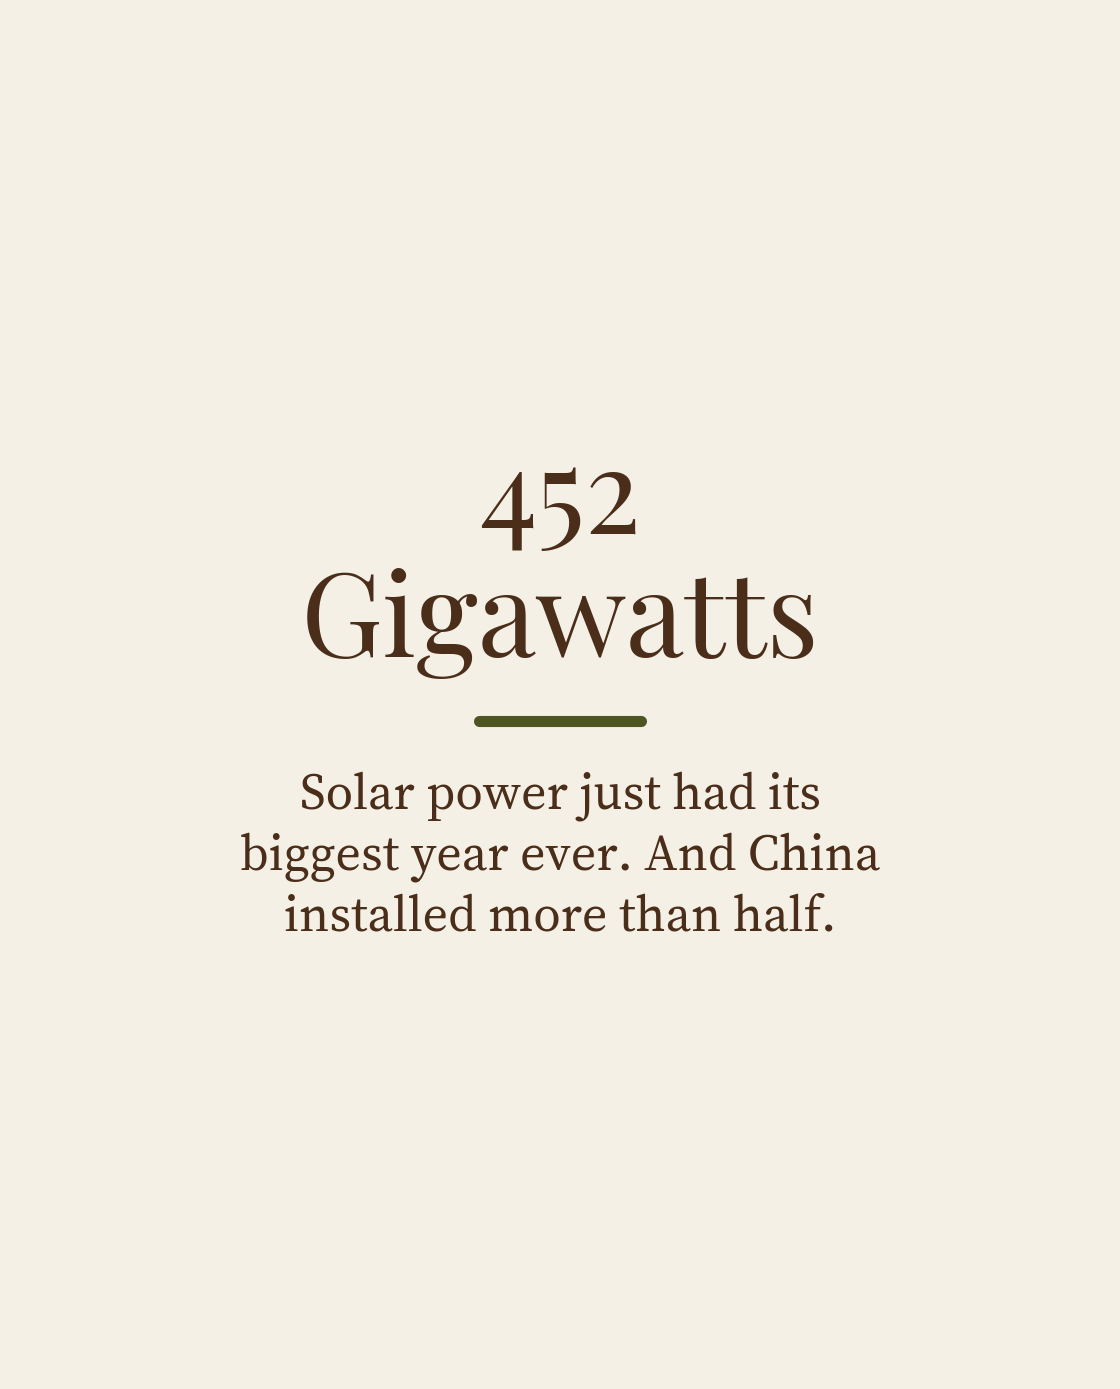

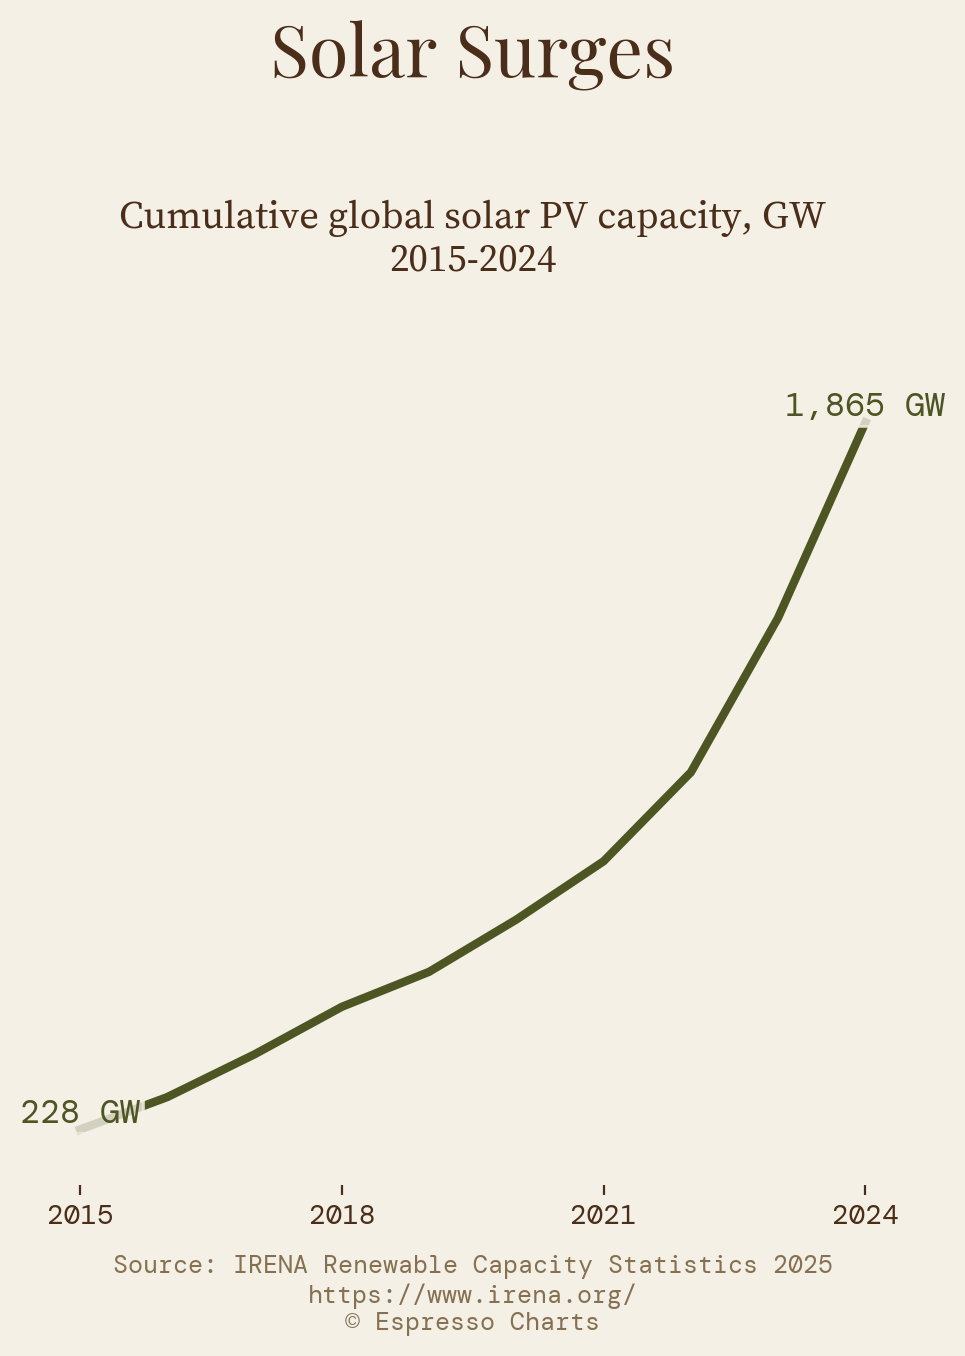

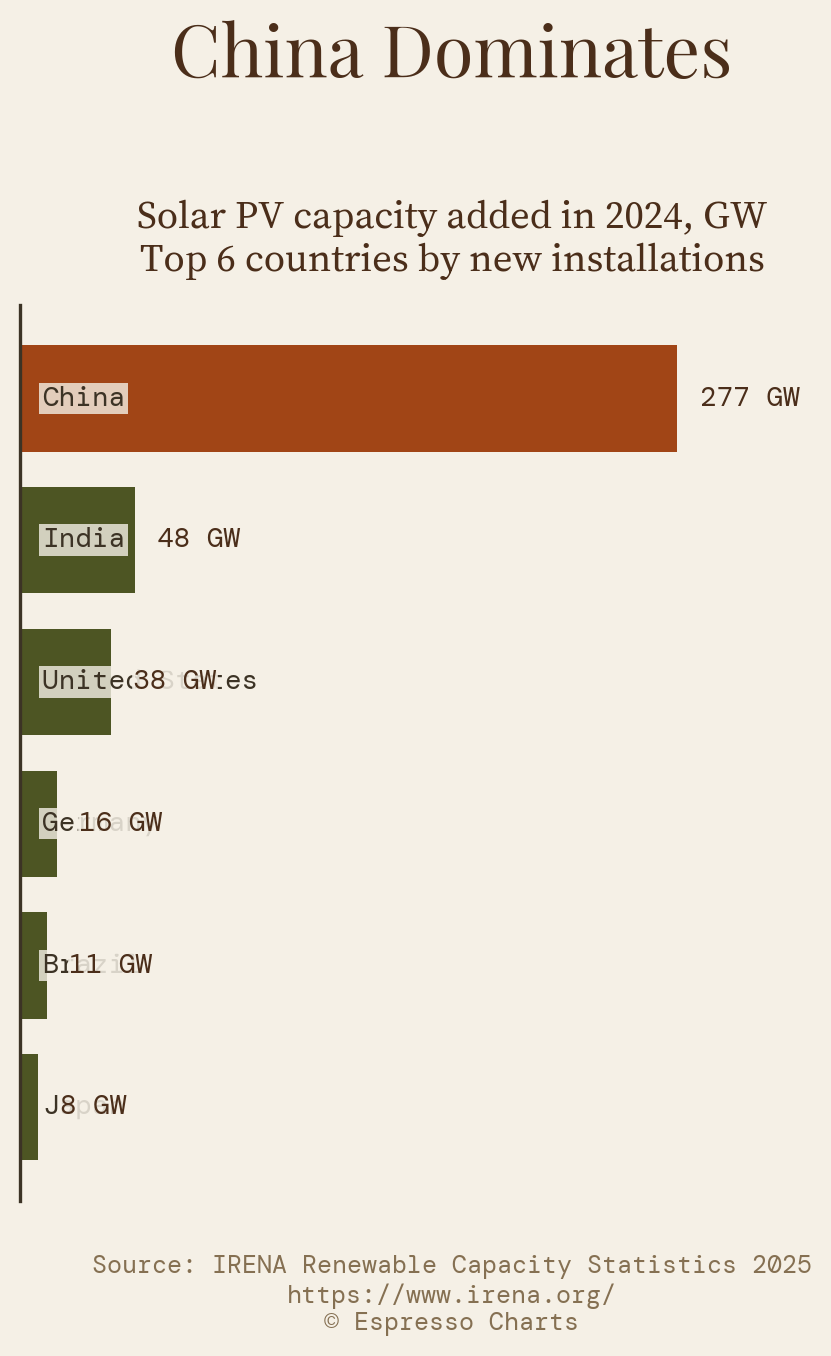

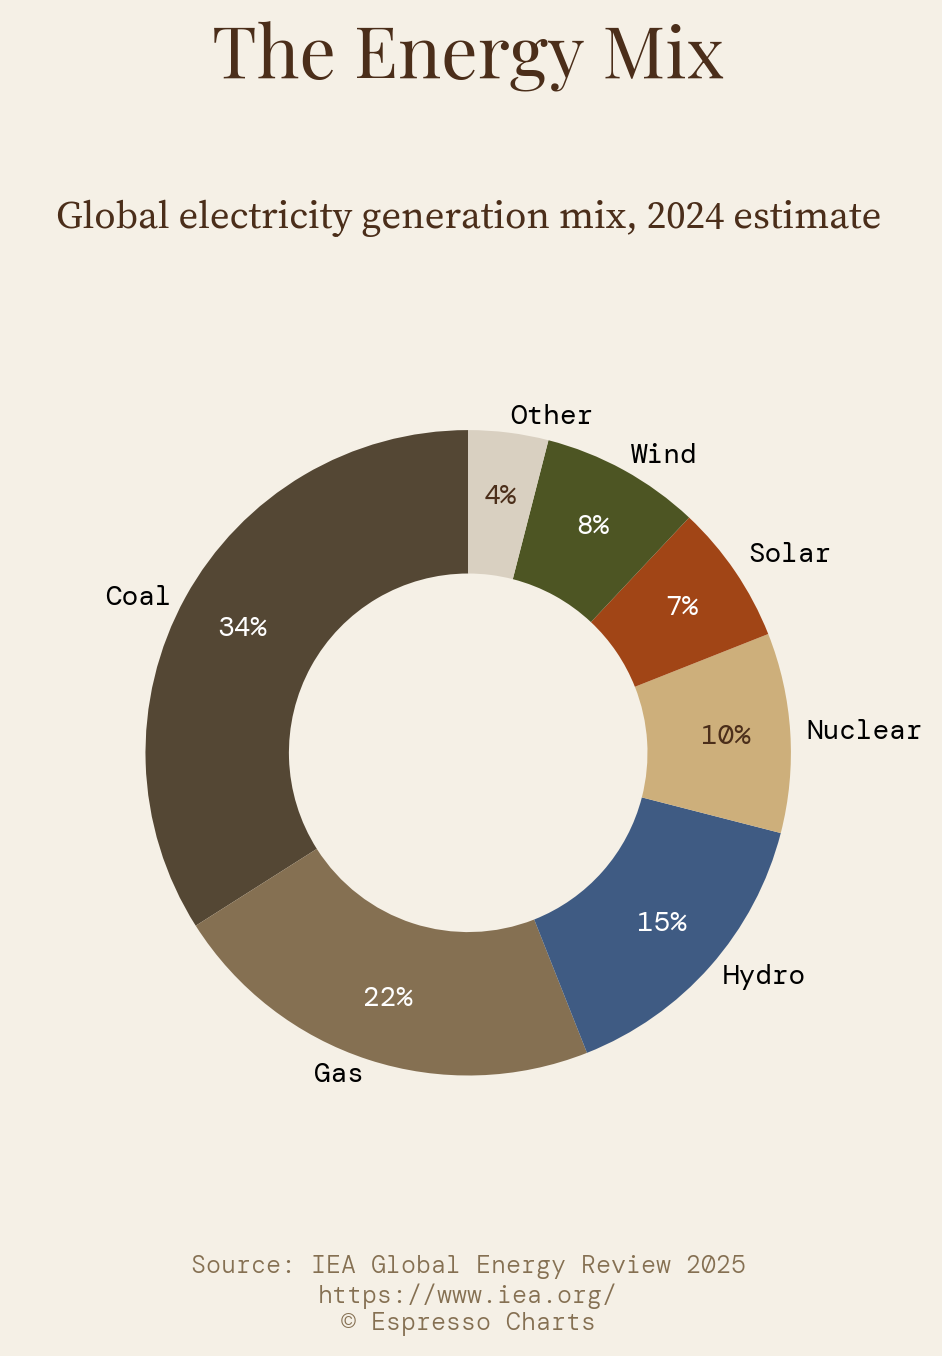

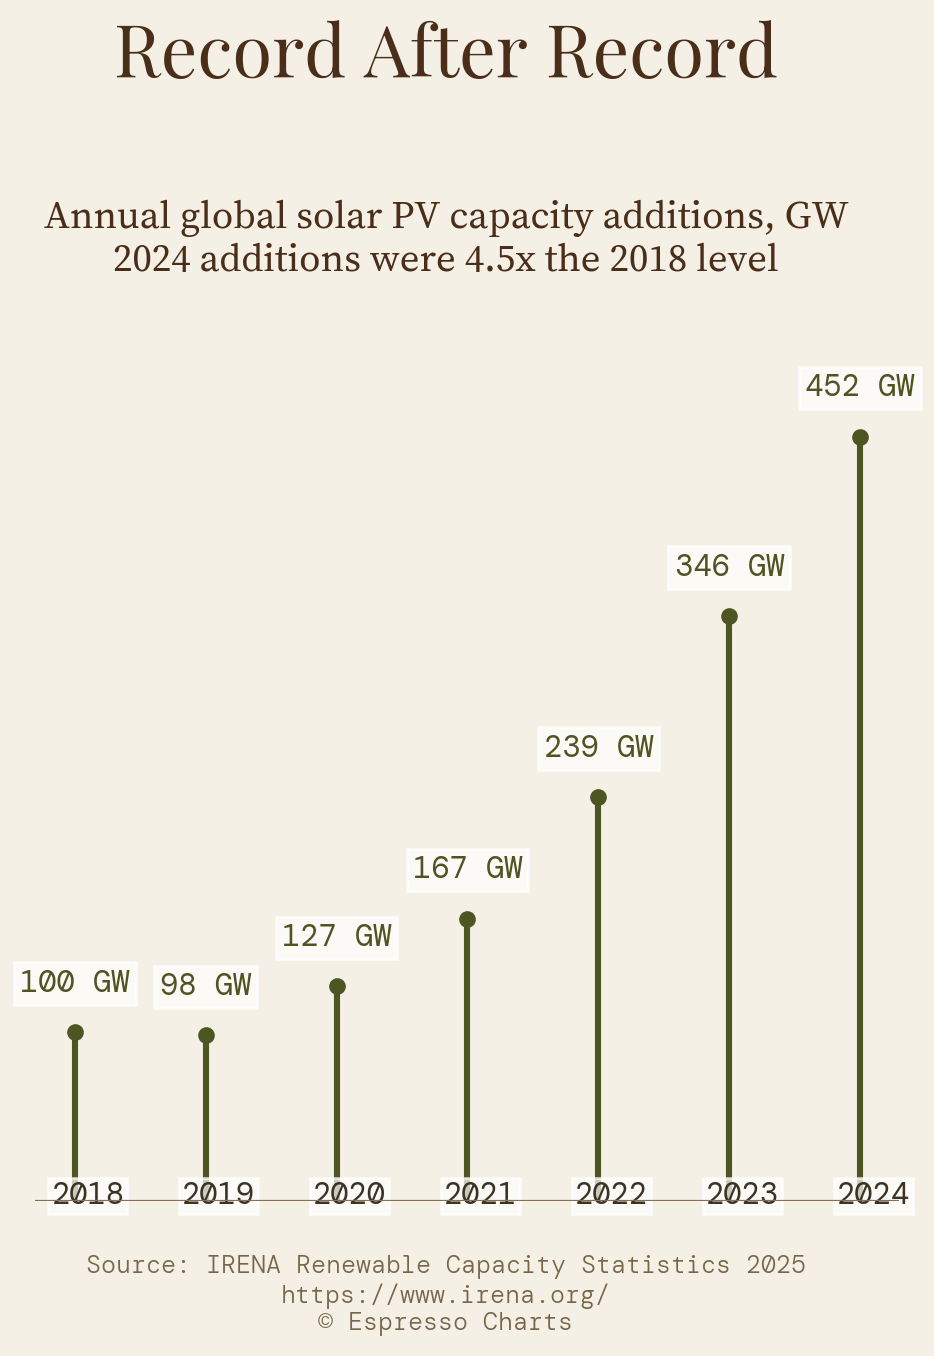

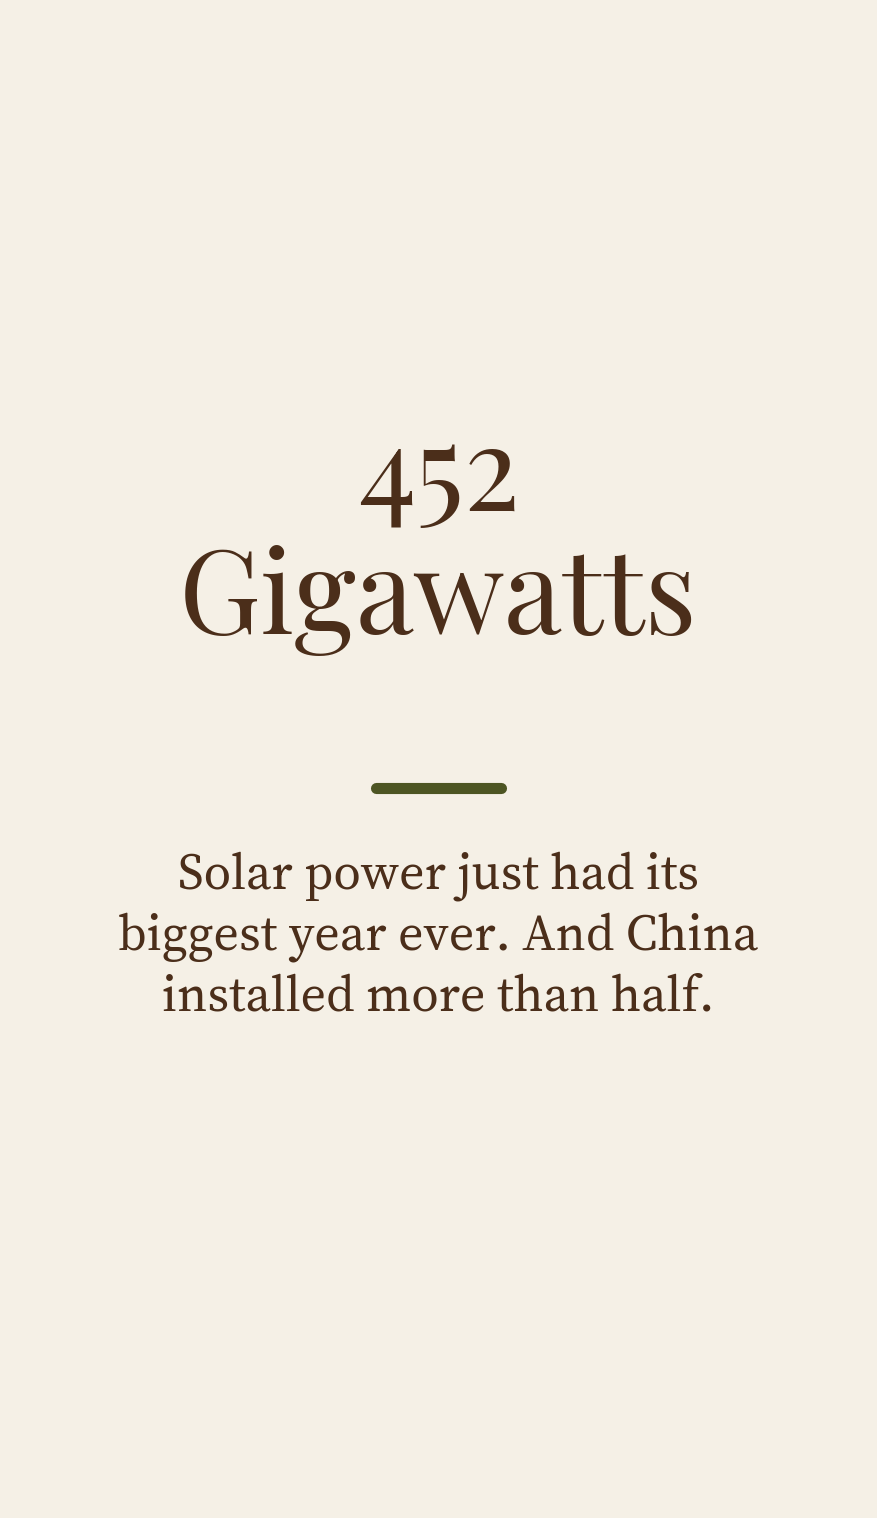

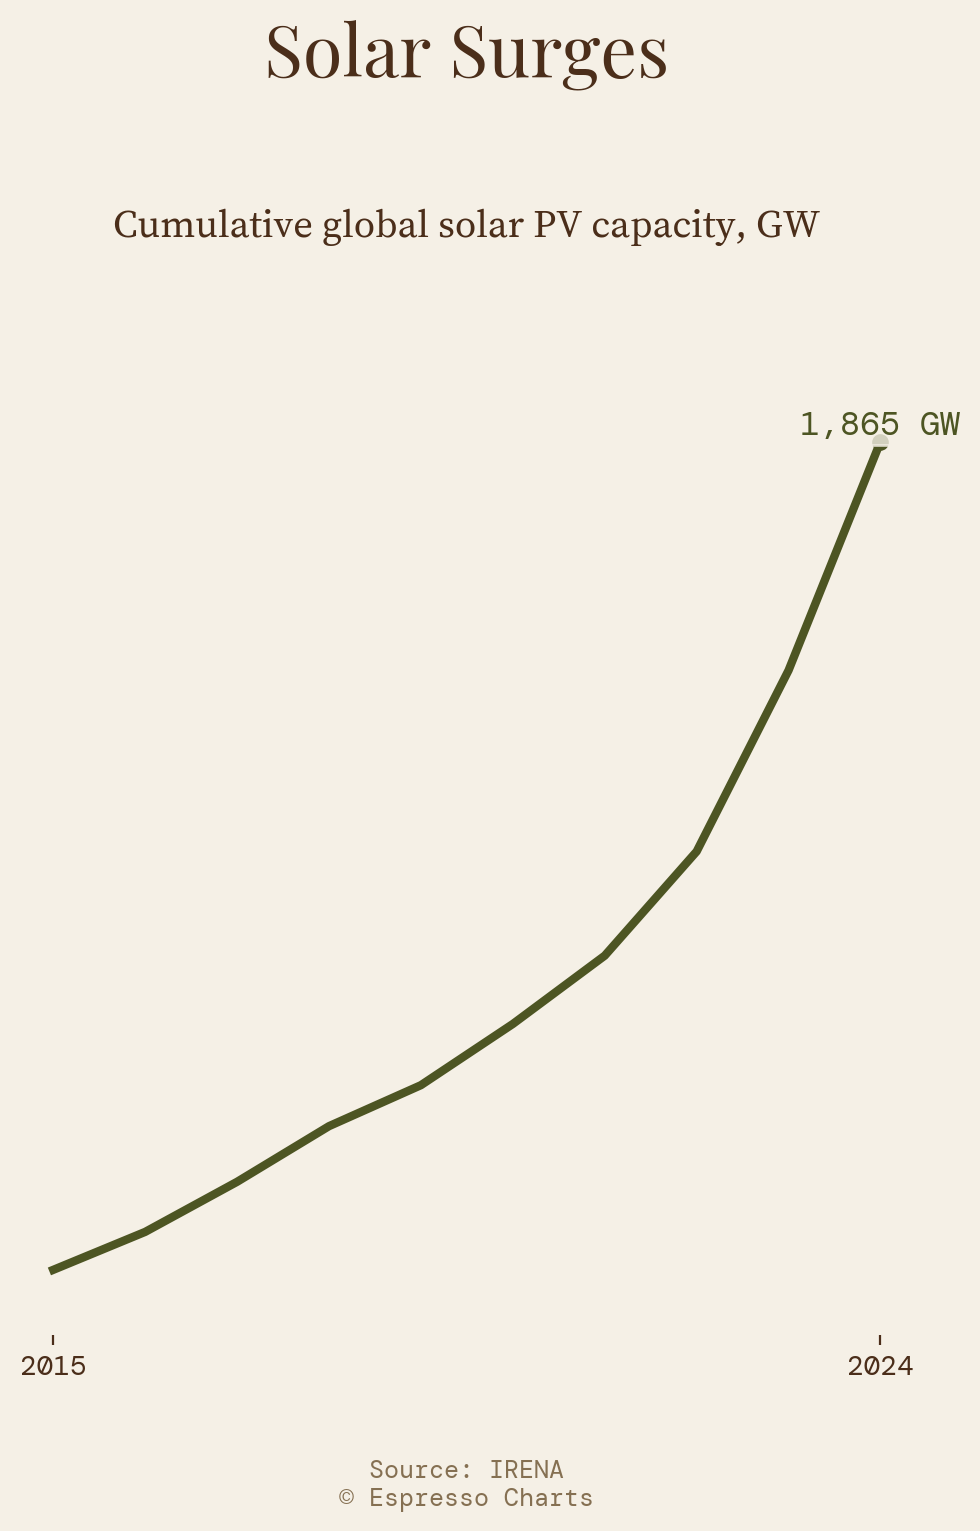

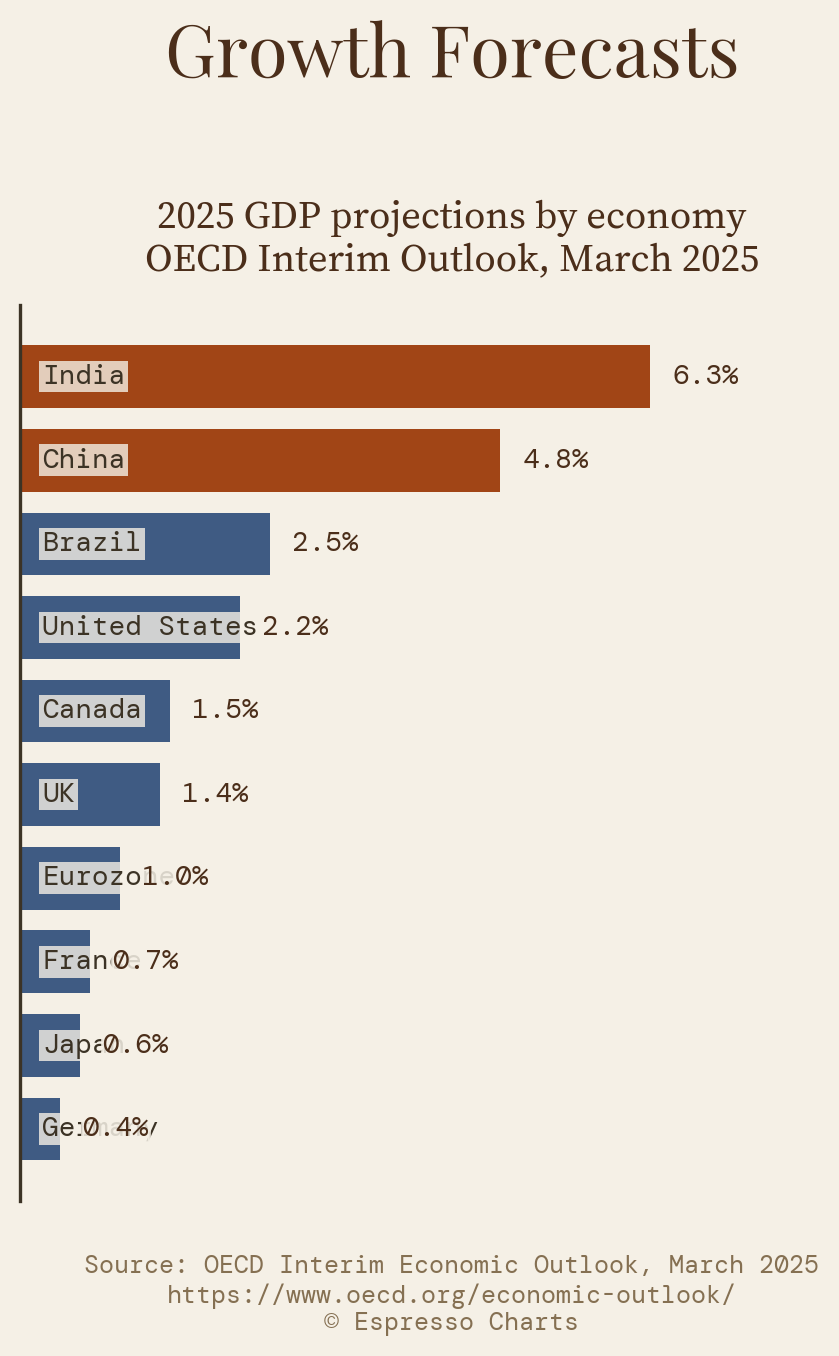

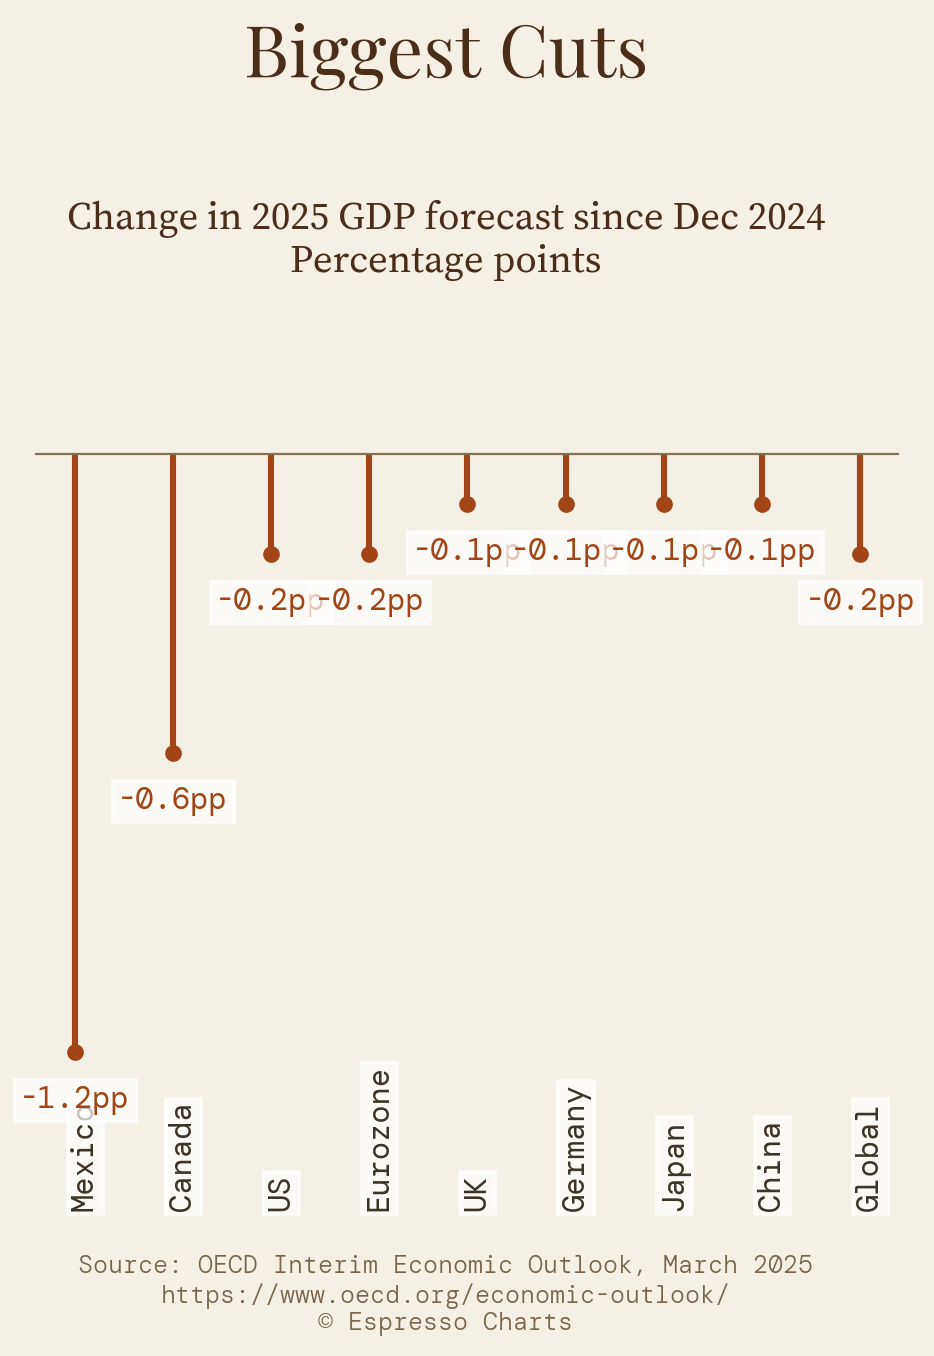

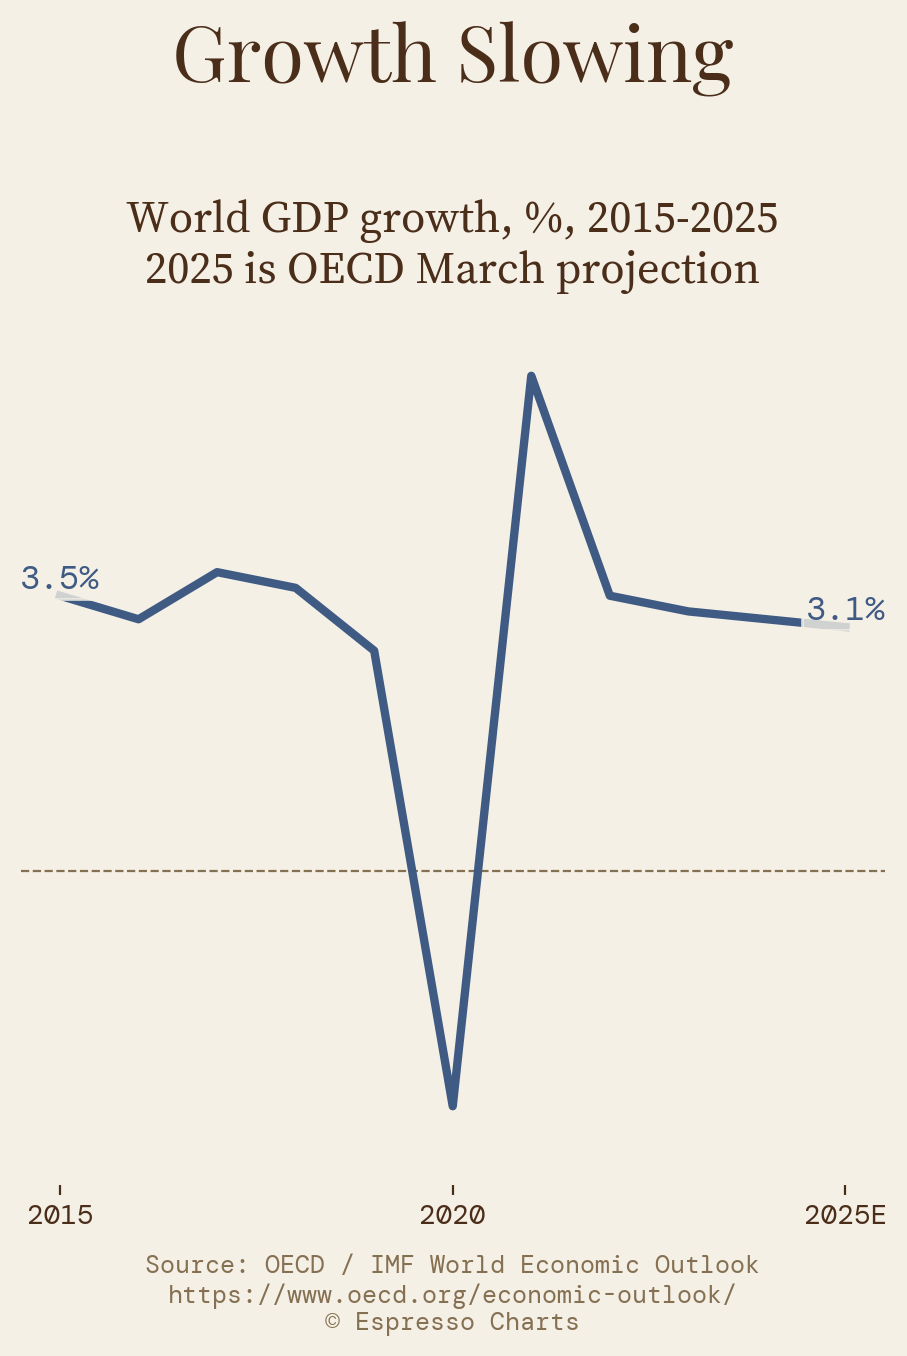

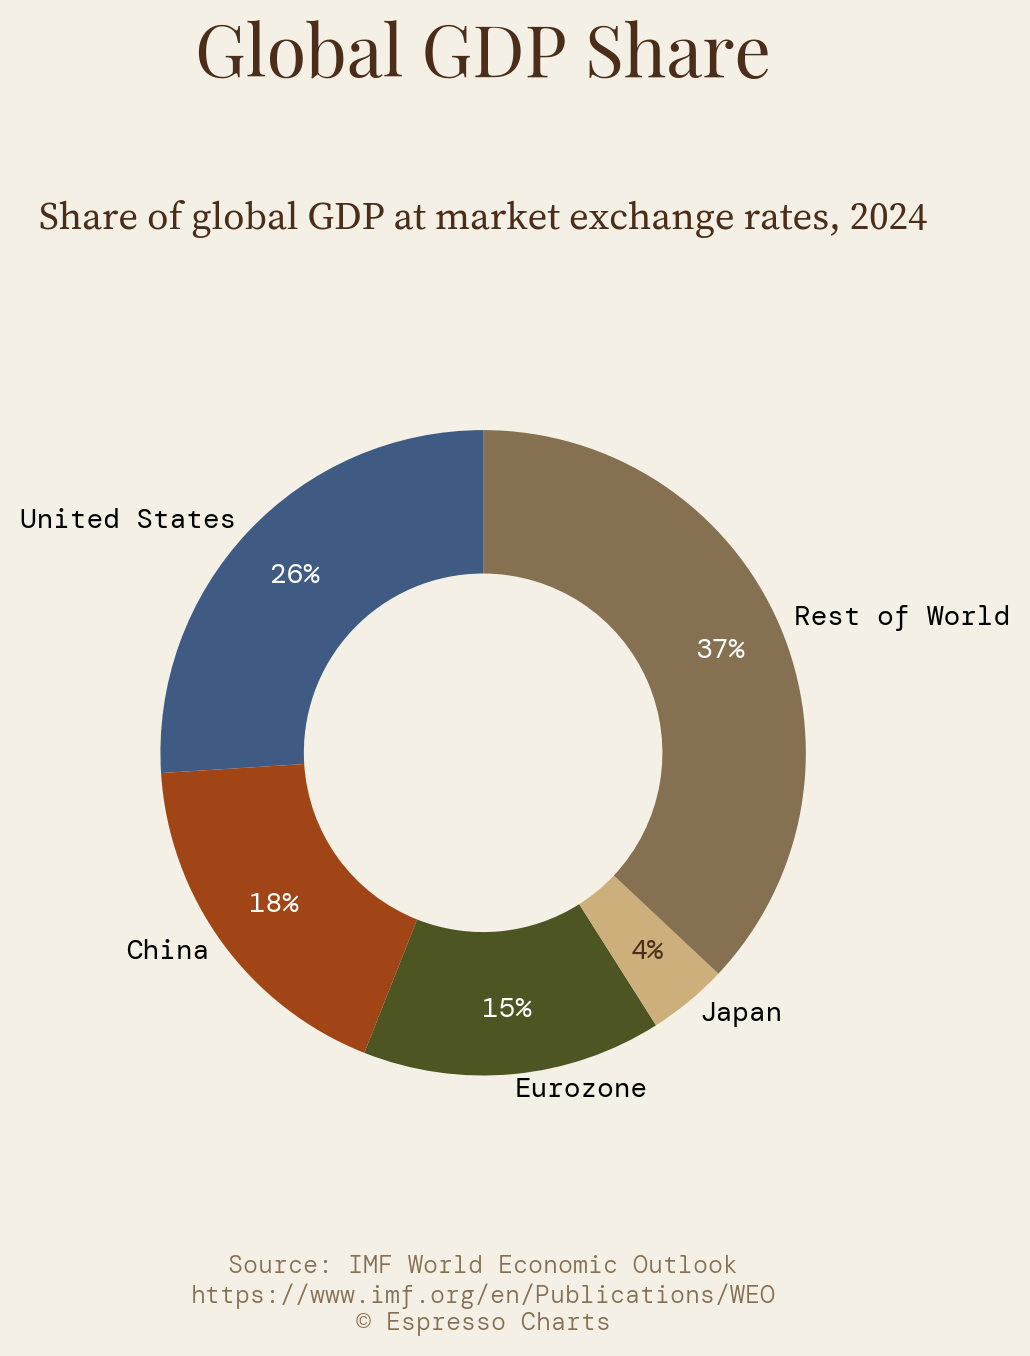

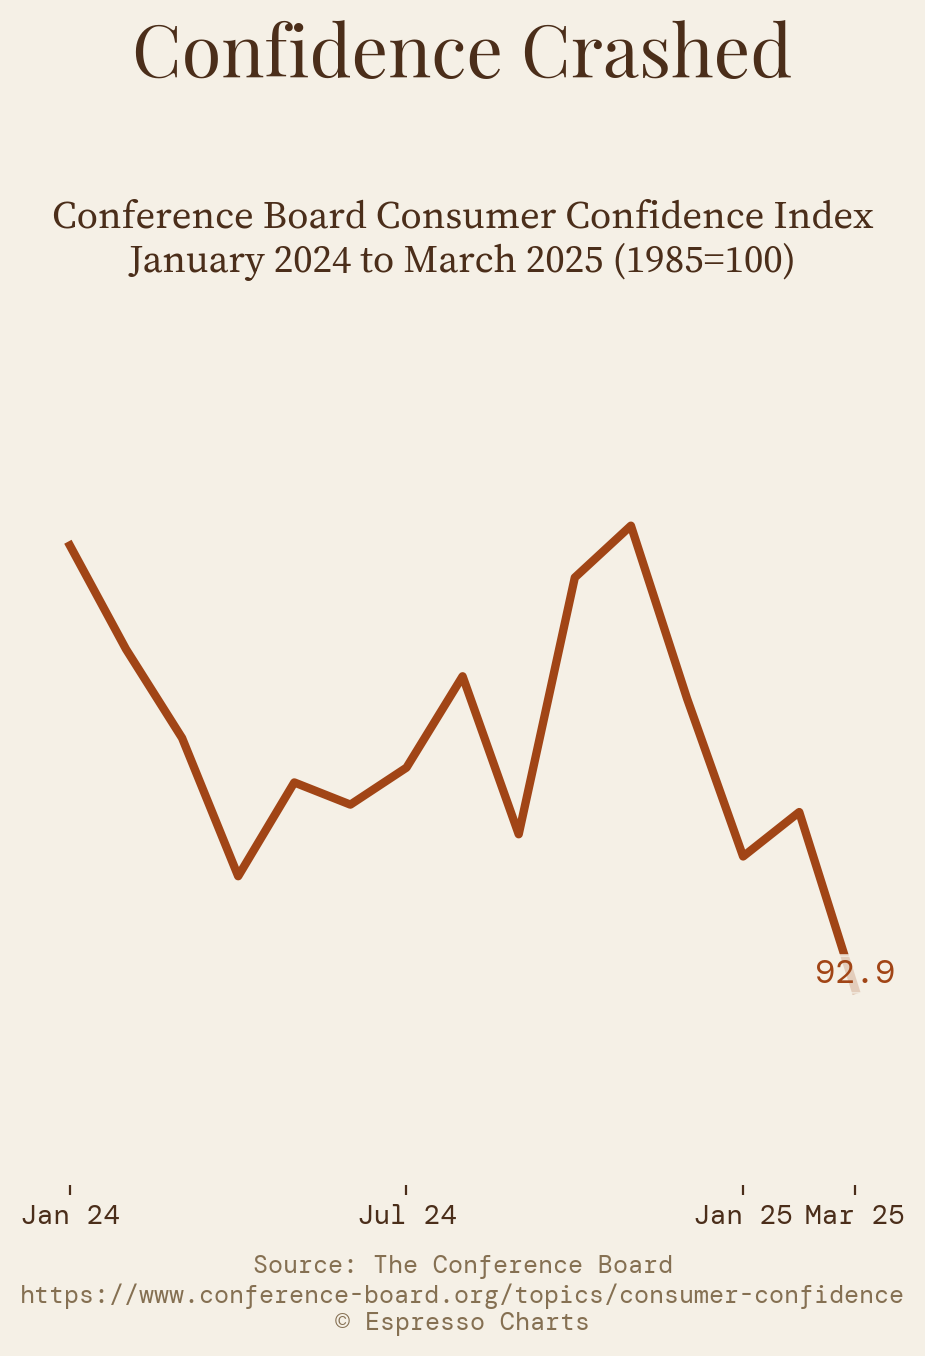

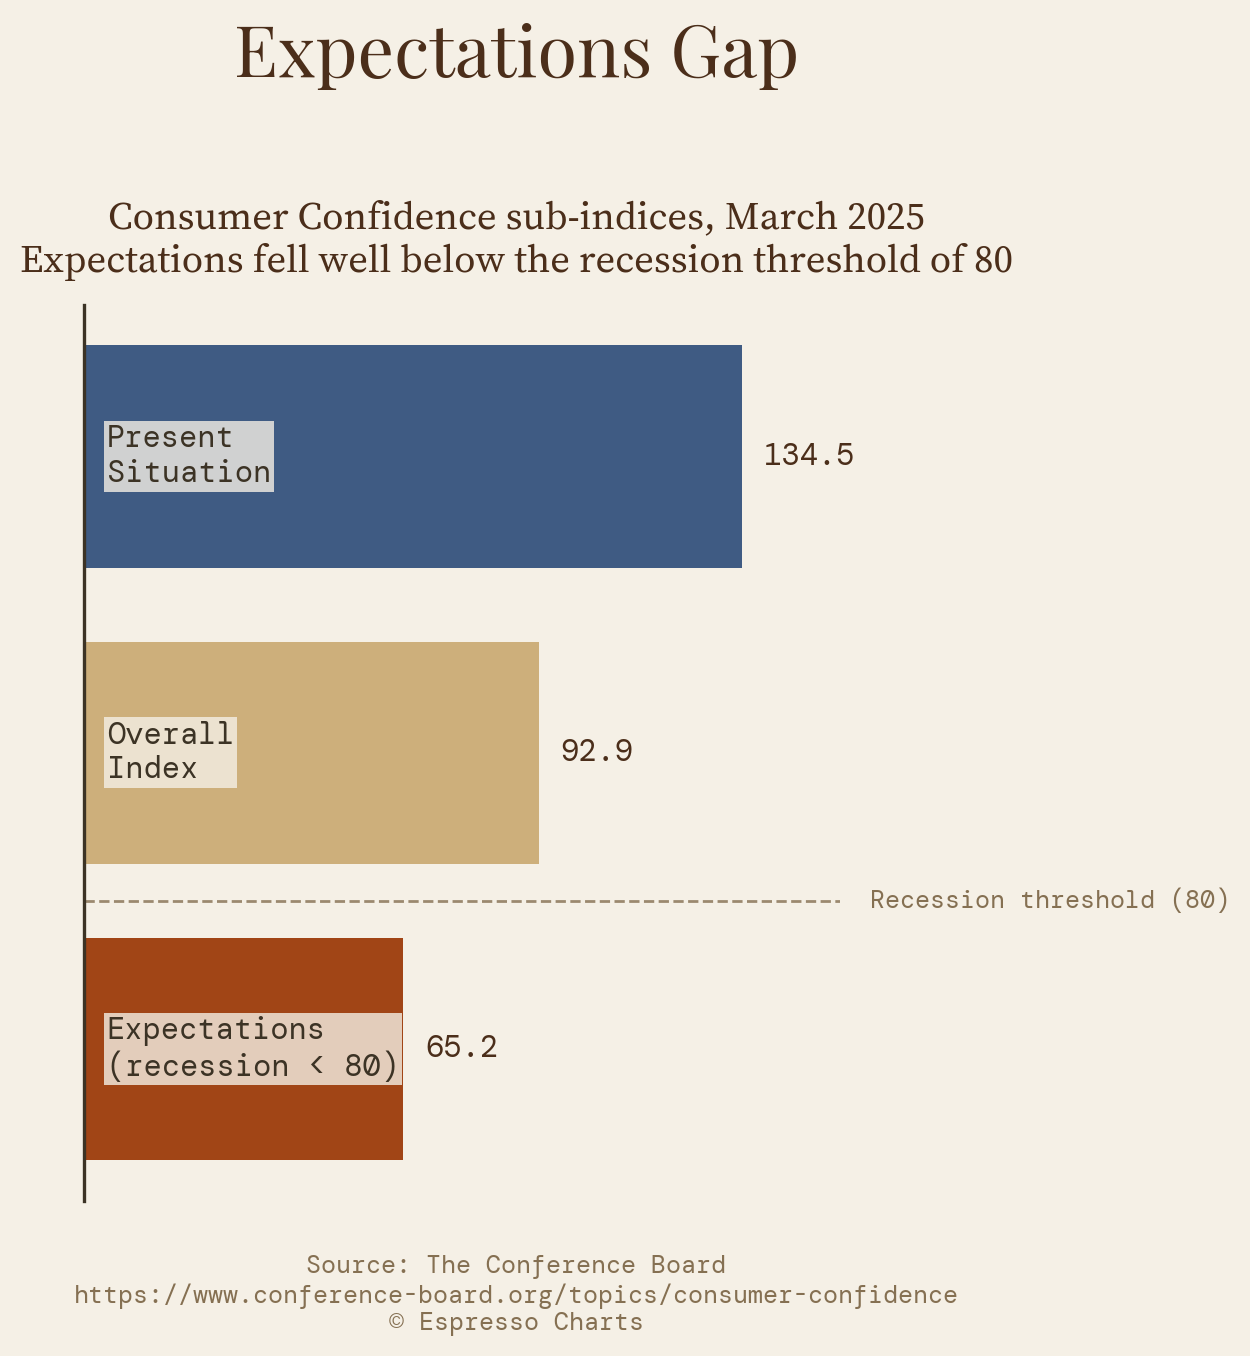

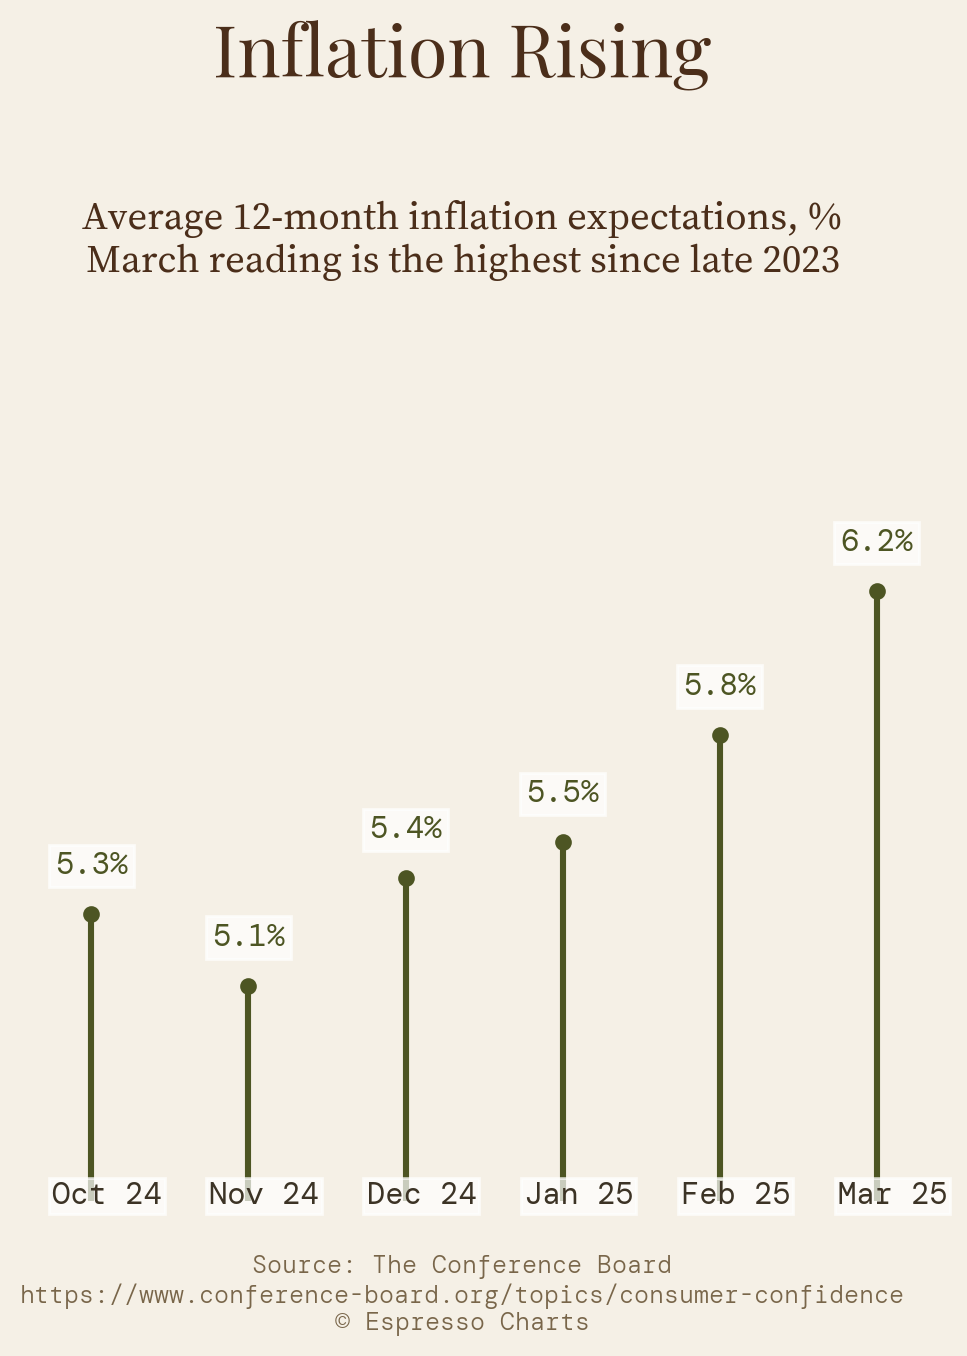

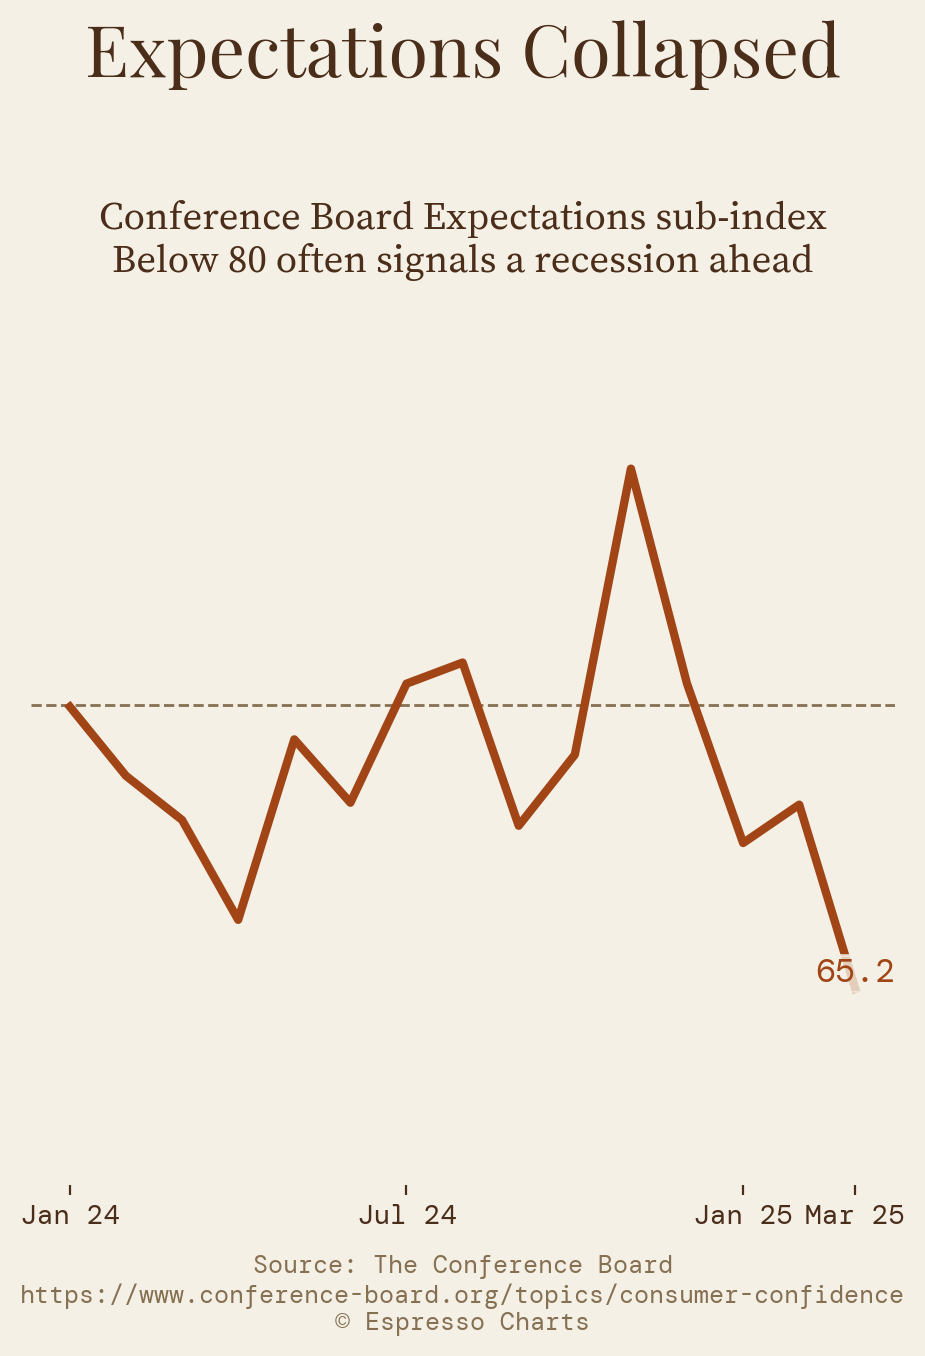

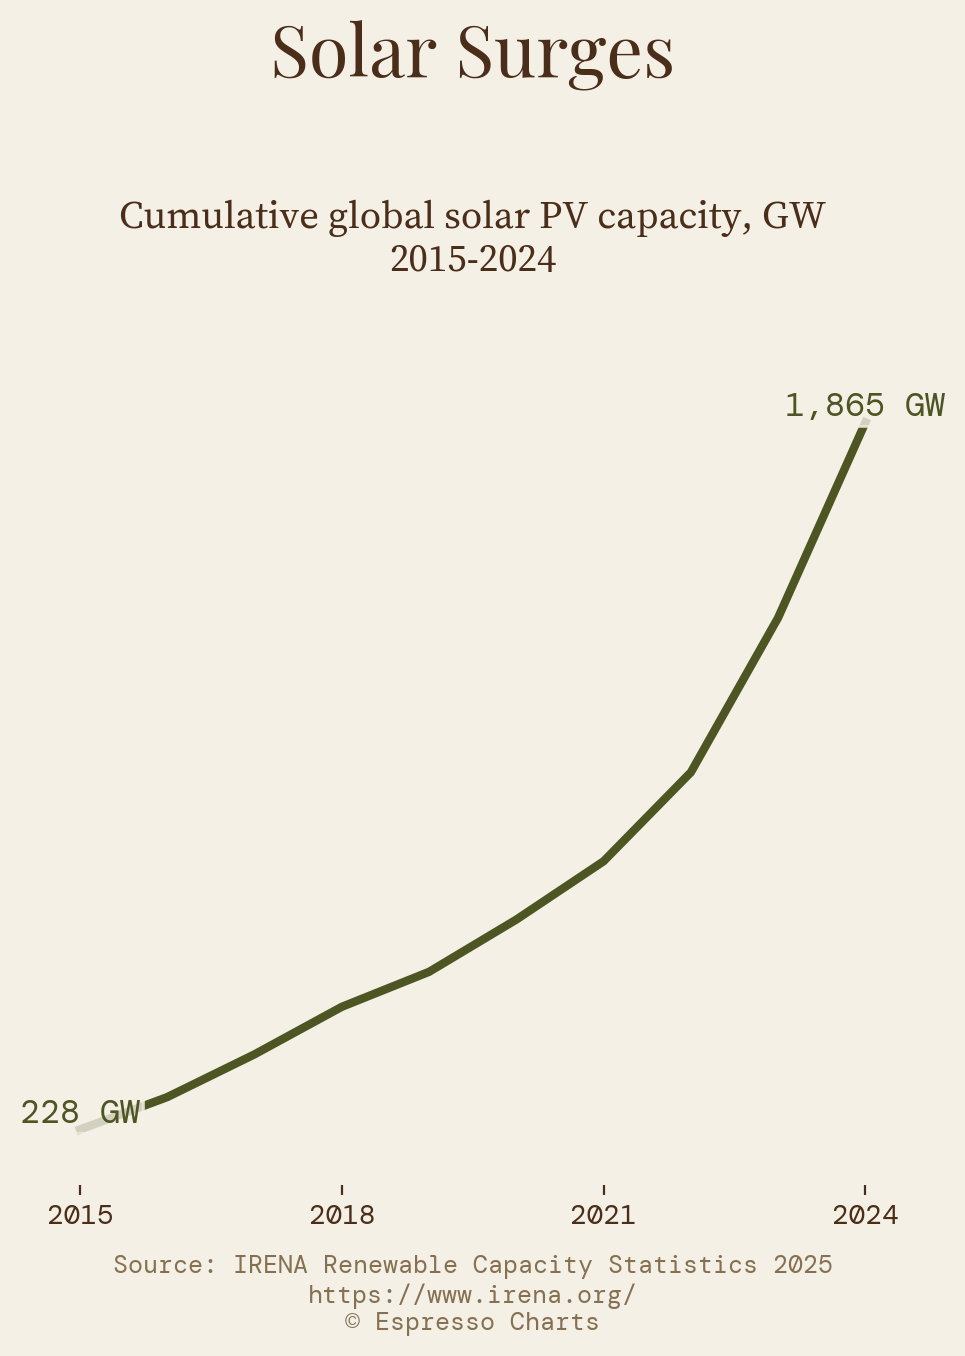

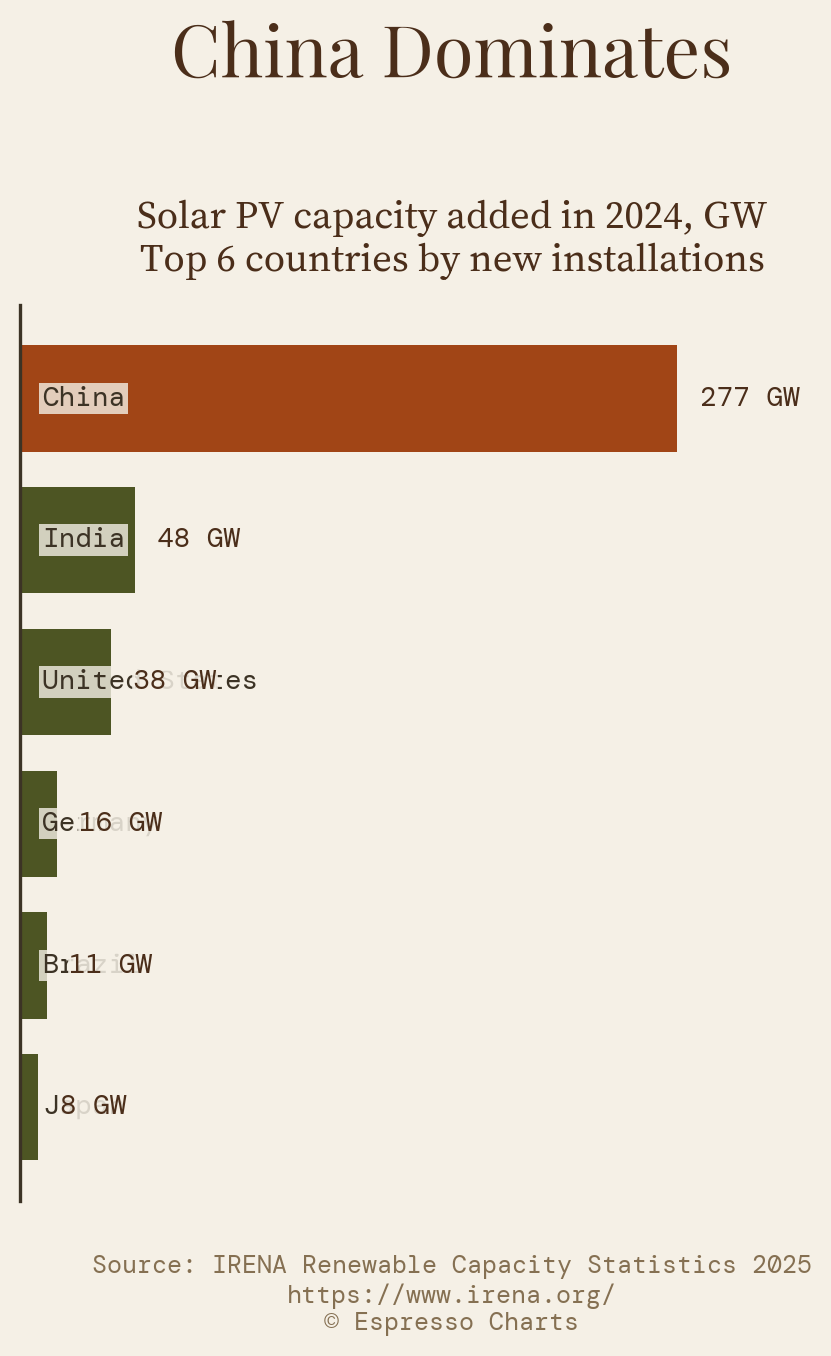

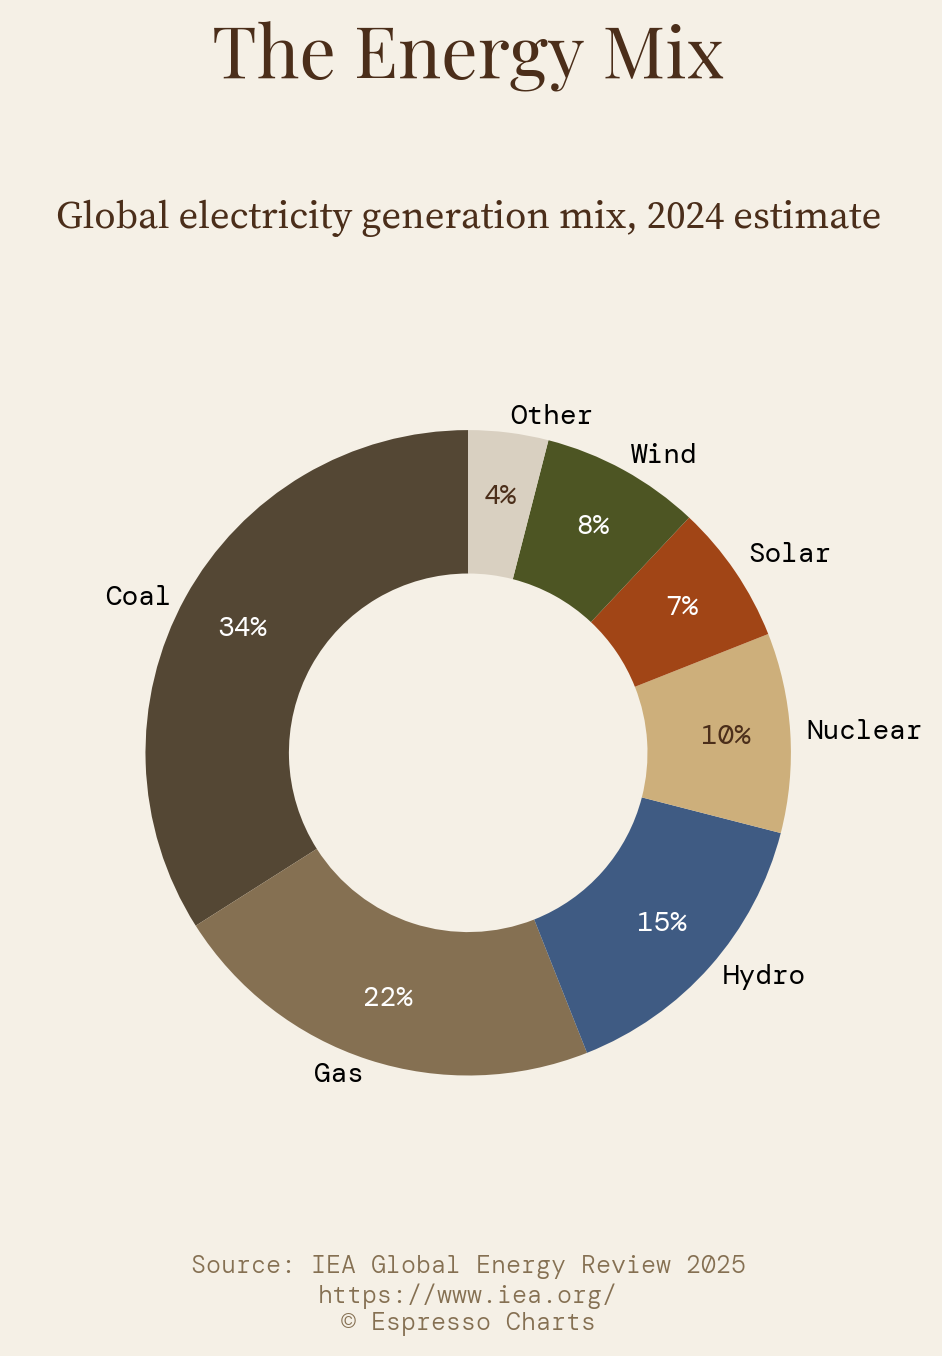

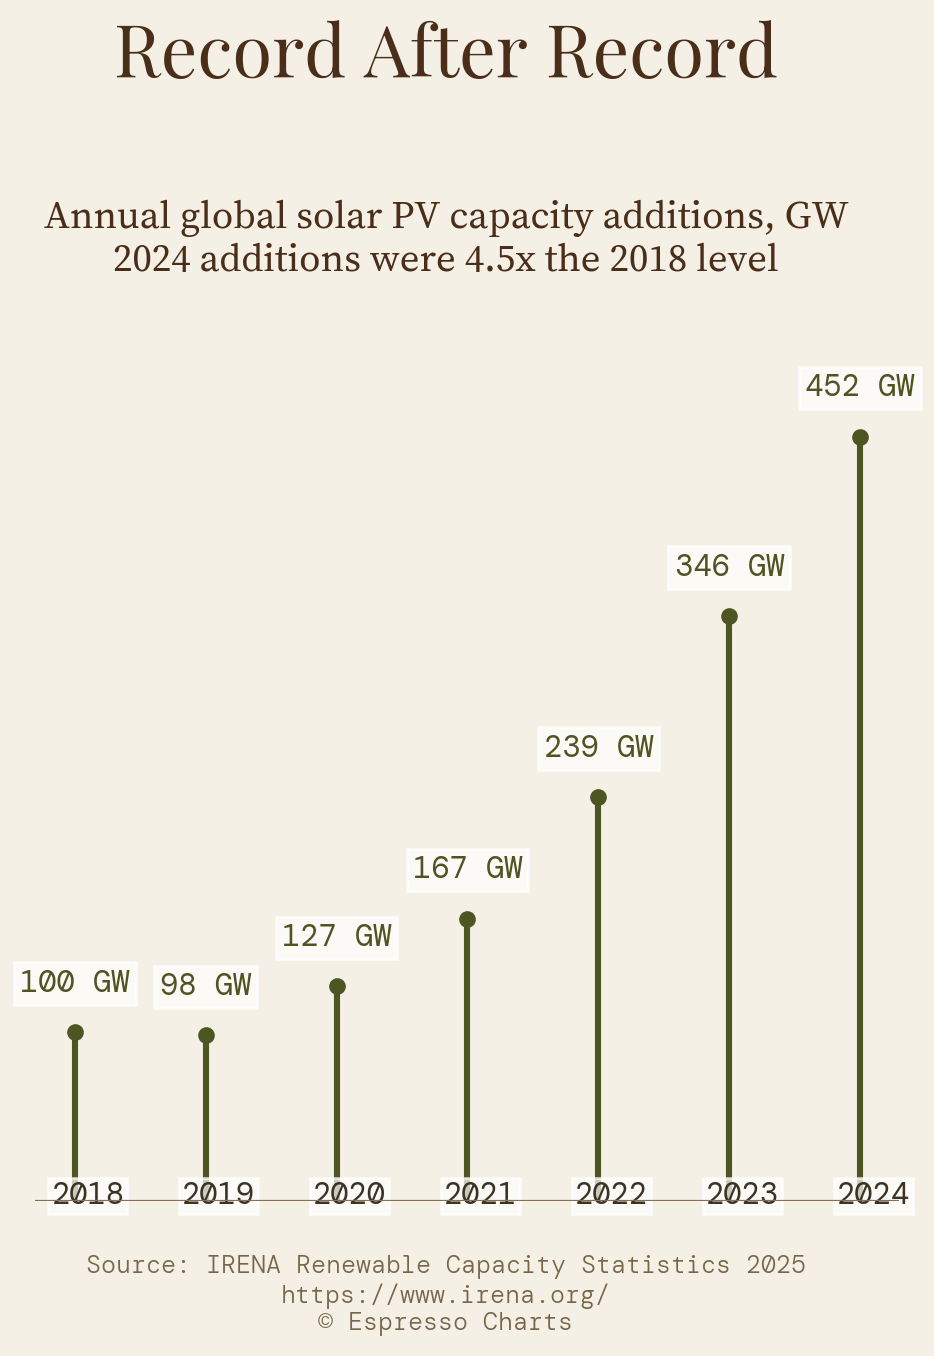

In [ ]:
# INDIVIDUAL CREATION OF ASSETS

# Just story 2, everything
run_config(config, story_ids=2)

# Story 1, only the second chart
#run_config(config, story_ids=0, only='stem_animate', chart_indices=1)
#run_config(config, story_ids=2, only='reel')

# Generate carousels
run_config(config, story_ids=0, only='charts') #, chart_indices=1)
run_config(config, story_ids=1, only='charts') #, chart_indices=1)
run_config(config, story_ids=2, only='charts') #, chart_indices=2)

# Regenerate just the cover for story 0
#run_config(config, story_ids=0, only='cover')

# Only reels for stories 1 and 3
#run_config(config, story_ids=0)
#run_config(config, story_ids=[1], only='reel')
#run_config(config, story_ids=[2], only='reel')

# All PNGs, no video
#run_config(config, only=['cover', 'charts'])
#run_config(config, story_ids=0, only=['line_animate']) #line_animate, stem_animate


In [ ]:
import inspect
src = inspect.getsource(eGenerateOpeningFrame)
print("has debug dump" if "Debug: show all" in src else "has video.save fix")

has video.save fix


In [ ]:
import inspect
src = inspect.getsource(eGenerateOpeningFrame)
print("has debug dump" if "Debug: show all" in src else "has video.save fix")

has video.save fix


In [ ]:
# Force reload from disk
import importlib, espresso_charts
importlib.reload(espresso_charts)
from espresso_charts import *

# Verify
import inspect
src = inspect.getsource(eGenerateOpeningFrame)
print("has debug dump" if "Debug: show all" in src else "has video.save fix")

has video.save fix


In [ ]:
!grep -c "Debug: show all" /content/espresso_charts.py

0


In [ ]:
import importlib, espresso_charts
importlib.reload(espresso_charts)
from espresso_charts import *

# Verify
import inspect
src = inspect.getsource(eGenerateOpeningFrame)
print("has debug dump" if "Debug: show all" in src else "has video.save fix")

has video.save fix


# Run all

In [ ]:
#run_config(config)